<a href="https://colab.research.google.com/github/pinfada/jiyufit-modele-concurrentiel/blob/main/jiyufit_modele_concurrentiel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modèle JiyuFit — Capture Concurrentielle à Capital de Réseau

**Objectif de cette section :** (1) retranscrire proprement en LaTeX les équations du rapport technique, (2) vérifier leur cohérence mathématique (dérivations, cas limites, conditions d'équilibre), (3) implémenter le modèle en Python/NumPy pour simuler sa dynamique.

On étudie $n$ plateformes concurrentes indexées par $i \in \{1,\dots,n\}$, observées à des périodes discrètes $t = 0,1,\dots,T$, dans une ville $v$. L'état de la plateforme $i$ est le vecteur

$$\mathcal{S}_{i,v}(t) = \big[\, k_{i,v}(t),\; N_{1,i,v}(t),\; N_{2,i,v}(t) \,\big]$$

où $k_{i,v}(t)$ est le capital de réseau accumulé, $N_{1,i,v}(t) = N_{s,v}(t)$ la population des sportifs actifs, et $N_{2,i,v}(t) = N_{l,v}(t)$ la population des lieux partenaires actifs.

## II. Bloc concurrentiel et capture

**Effort concurrentiel effectif.** L'effort brut $x_{i,v}(t)$ est amplifié par le capital de réseau historique :
$$e_{i,v}(t) = k_{i,v}(t) \cdot x_{i,v}(t)$$

**Fonction générale de capture (Tullock généralisée, $n$ plateformes, sensibilité $r>0$) :**

$$P_{i,v}(t) = \frac{[k_{i,v}(t) x_{i,v}(t)]^r}{\sum_{m=1}^{n} [k_{m,v}(t) x_{m,v}(t)]^r}, \qquad \sum_{i=1}^{n} P_{i,v}(t) = 1$$

**Cas du duel JiyuFit ($J$) vs rival agrégé ($m$), sensibilité linéaire $r=1$ :**

$$P_{J,v}(t) = \frac{k_{J,v}(t) x_{J,v}(t)}{k_{J,v}(t) x_{J,v}(t) + k_{m,v}(t) x_{m,v}(t)}$$

## III. Bloc de valeur biface et multiplicateurs qualitatifs

**Face Sportifs effectifs.** Les volumes bruts sont pondérés par la qualité d'engagement de chaque utilisateur $u$ :
$$N_{s,v}^{eff}(t) = \sum_{u=1}^{N_{s,v}(t)} r_u(t), \qquad r_u(t) = \mu_1 \text{Reservations}_u + \mu_2 \text{Fiabilite}_u + \mu_3 \text{TrustScore}_u + \mu_4 \text{Gouvernance}_u$$

**Face Lieux effectifs.** Les infrastructures partenaires (hôtels, piscines, salles) sont pondérées par leur qualité $q_h(t)$:
$$N_{l,v}^{eff}(t) = \sum_{h=1}^{N_{l,v}(t)} q_h(t), \qquad q_h(t) = \lambda_1 \text{Capacite}_h + \lambda_2 \text{Localisation}_h + \lambda_3 \text{Disponibilite}_h - \lambda_4 \text{RisquePercu}_h$$

**Valeur économique nette capturable.** Elle intègre l'effet de réseau croisé $d_{sl}$ (densité biface) :
$$V_{J,v}(t) = p_s N_{s,v}^{eff}(t) + p_l N_{l,v}^{eff}(t) + d_{sl}\big[N_{s,v}^{eff}(t) N_{l,v}^{eff}(t)\big] - c_s N_{s,v}(t) - c_l N_{l,v}(t)$$

avec $p_s, p_l$ les gains unitaires directs, $c_s, c_l$ les coûts marginaux de gestion/onboarding, et le terme croisé $d_{sl}[N_{s,v}^{eff} N_{l,v}^{eff}]$ représentant la densité biface locale (rencontres physiques potentielles).

## IV. Équation maîtresse du gain espéré

L'espérance de profit par période combine capture et valeur, moins l'effort et la barrière d'entrée $b_{J,v}$:$$\mathbb{E}(G_{J,v}(t)) = P_{J,v}(t) \cdot V_{J,v}(t) - x_{J,v}(t) - b_{J,v}$$

En substituant $P_{J,v}(t)$ et $V_{J,v}(t)$, on obtient l'équation maîtresse complète :$$\mathbb{E}(G_{J,v}(t)) = \left[\frac{k_{J,v}(t)x_{J,v}(t)}{k_{J,v}(t)x_{J,v}(t) + \sum_m k_{m,v}(t)x_{m,v}(t)}\right] \cdot \left[p_s N_{s,v}^{eff}(t) + p_l N_{l,v}^{eff}(t) + d_{sl}\big(N_{s,v}^{eff}(t) N_{l,v}^{eff}(t)\big) - c_s N_{s,v}(t) - c_l N_{l,v}(t)\right] - x_{J,v}(t) - b_{J,v}$$

## V. Équilibre de Nash et effort concurrentiel optimal

**Meilleure réponse.** La condition de premier ordre $\partial \mathbb{E}(G_{J,v})/\partial x_{J,v} = 0$, face à un rival de puissance $e_{m,v}(t) = k_{m,v}(t)x_{m,v}(t)$ fixée, donne l'effort optimal:$$x_{J,v}^*(t) = \max\left\{0,\; \sqrt{\frac{k_{m,v}(t)x_{m,v}(t)V_{J,v}(t)}{k_{J,v}(t)}} - \frac{k_{m,v}(t)x_{m,v}(t)}{k_{J,v}(t)}\right\}$$

**Condition d'effort intérieur positif.** JiyuFit maintient un effort actif ($x_{J,v}^* > 0$) seulement si:$$V_{J,v}(t) > \frac{k_{m,v}(t)x_{m,v}(t)}{k_{J,v}(t)}$$

Sinon, $x_{J,v}^*=0$ : la plateforme cesse d'investir.

**Loi d'asymétrie radicale.** Quand le capital de réseau devient massif ($k_{J,v} \to \infty$), le système converge vers:$$\lim_{k_{J,v}\to\infty} x_{J,v}^*(t) = 0 \qquad \text{et} \qquad \lim_{k_{J,v}\to\infty} P_{J,v}(t) = 1$$

La plateforme dominante capture tout le marché sans effort marginal publicitaire.

## VI. Dynamique des populations avec saturation logistique

Pour éviter toute divergence irréaliste, les équations d'évolution intègrent un facteur logistique basé sur la capacité de charge maximale du marché local ($K_s$ pour les sportifs, $K_l$ pour les lieux).

**Face Sportifs actifs (dynamique saturée).**

$$N_{s,v}(t+1) = (1-\chi_s)N_{s,v}(t) + \left(1 - \frac{N_{s,v}(t)}{K_s}\right)\Big[a_1 P_{J,v}(t) + a_2 N_{l,v}(t) + a_3 Q_J(t) + a_4 M_J(t) + a_5 F_J(t)\Big]$$

avec $\chi_s$ le taux de churn (volatilité) des sportifs, et $F_J(t)$ la force d'attraction de la promesse "sans abonnement, sans captivité".

**Face Lieux partenaires (dynamique saturée).**

$$N_{l,v}(t+1) = (1-\chi_l)N_{l,v}(t) + \left(1 - \frac{N_{l,v}(t)}{K_l}\right)\Big[s_1 P_{J,v}(t) + s_2 N_{s,v}(t) + s_3 Q_J(t) + s_4 B_l(t) + s_5 Z_J(t)\Big]$$

avec $\chi_l$ le taux de churn des lieux, $B_l(t)$ le bénéfice économique direct perçu par les hôtels (monétisation des actifs dormants), et $Z_J(t)$ la simplicité opérationnelle et technique (accès QR code automatisé).

## VII. Dynamique d'accumulation du capital de réseau

Le capital réseau local, mémoire économique et historique de JiyuFit dans la ville $v$, évolue selon une accumulation linéaire (sans saturation):

$$k_{J,v}(t+1) = (1-\delta_k)k_{J,v}(t) + \alpha P_{J,v}(t) + \beta_s N_{s,v}^{eff}(t) + \beta_l N_{l,v}^{eff}(t) + \gamma R_{J,v}(t) + \eta G_{J,v}(t)$$

où $\delta_k$ est la perte naturelle d'autorité (attention web), $\alpha$ le multiplicateur d'une victoire concurrentielle immédiate, $\beta_s, \beta_l$ les contributions directes de l'usage des sportifs et des lieux, $R_{J,v}(t)$ la réputation (backlinks locaux, preuves sociales), et $G_{J,v}(t)$ la force de la gouvernance communautaire (TrustScore, votes, avis).

## VIII. Conditions de bascule et théorème de densité locale

**Condition de bascule relative.** JiyuFit creuse définitivement l'écart si le ratio des capitaux augmente:

$$\frac{k_{J,v}(t+1)}{k_{m,v}(t+1)} > \frac{k_{J,v}(t)}{k_{m,v}(t)} \iff \frac{\Delta k_{J,v}(t)}{k_{J,v}(t)} > \frac{\Delta k_{m,v}(t)}{k_{m,v}(t)}$$

**Condition de domination asymptotique (winner-takes-most).** Si la densité biface franchit un seuil critique $D_v(t) = N_{s,v}^{eff}(t)\cdot N_{l,v}^{eff}(t) \geq D_{min}$ pendant plusieurs périodes consécutives, le marché se verrouille:

$$\lim_{t\to\infty} P_{J,v}(t) = 1 \qquad \text{et} \qquad \lim_{t\to\infty} P_{m,v}(t) = 0$$

**Théorème de densité locale JiyuFit.** Dans un marché physique bilatéral, la concentration de l'effort concurrentiel sur une seule ville $v^*$ démultiplie géométriquement la valeur de l'effet croisé $d_{sl}$ par rapport à une stratégie de dispersion multi-villes. La croissance n'est viable que si la masse critique locale est allumée en premier, permettant au capital de réseau de s'auto-alimenter pour autofinancer l'expansion future.

## IX. Conditions de survie et de sortie du marché

**Survie d'un nouvel entrant (barrière historique).** Pour s'imposer à $t=0$ face à un dominant installé, l'effort initial de JiyuFit doit compenser son déficit d'histoire, garantissant une part de marché minimale $\theta$:

$$x_{J,v}(0) \geq \frac{\theta}{1-\theta}\cdot\frac{k_{m,v}(0)}{k_{J,v}(0)}\cdot x_{m,v}(0)$$

**Condition de sortie (épuisement).** Si l'espérance de profit reste négative sur $L$ périodes consécutives:

$$\mathbb{E}(G_{J,v}(t-\ell)) < 0 \quad \forall \ell \in \{0,\dots,L-1\}$$

alors la plateforme est contrainte de couper les investissements et de quitter la ville.

## X. Vérification de la cohérence mathématique

Cette section vérifie algébriquement les dérivations clés du modèle, teste ses cas limites, et signale les points nécessitant une clarification.

### 1. Dérivation de la meilleure réponse (Section V)

En posant $e_J = k_{J,v}x_{J,v}$ et $e_m = k_{m,v}x_{m,v}$ fixé, on a $P_{J,v} = e_J/(e_J+e_m)$. La dérivée $\partial P_{J,v}/\partial x_{J,v} = k_{J,v}\, e_m/(e_J+e_m)^2$. La condition du premier ordre sur $\mathbb{E}(G_{J,v}) = P_{J,v}V_{J,v} - x_{J,v} - b_{J,v}$ donne $k_{J,v}e_m V_{J,v}/(e_J+e_m)^2 = 1$, soit $(e_J+e_m) = \sqrt{k_{J,v}e_m V_{J,v}}$, d'où $x_{J,v}^* = \sqrt{e_m V_{J,v}/k_{J,v}} - e_m/k_{J,v}$. **Ceci correspond exactement à la formule du rapport** (avec $e_m = k_{m,v}x_{m,v}$). La dérivée seconde $-2k_{J,v}^2 e_m/(e_J+e_m)^3 < 0$ confirme qu'il s'agit bien d'un maximum, pas d'un minimum.

### 2. Condition d'effort intérieur positif

$x_{J,v}^*>0 \iff \sqrt{e_m V_{J,v}/k_{J,v}} > e_m/k_{J,v}$. En élevant au carré (les deux membres sont positifs), $e_m V_{J,v}/k_{J,v} > e_m^2/k_{J,v}^2 \iff V_{J,v} > e_m/k_{J,v} = k_{m,v}x_{m,v}/k_{J,v}$. **Condition confirmée**, identique à celle du rapport.

### 3. Limite d'asymétrie radicale ($k_{J,v}\to\infty$)

$x_{J,v}^*(t) = \sqrt{e_m V_{J,v}}/\sqrt{k_{J,v}} - e_m/k_{J,v} \to 0$ quand $k_{J,v}\to\infty$ (les deux termes s'annulent). **Confirmé.** Mais l'effort effectif $e_J = k_{J,v}x_{J,v}^* = \sqrt{k_{J,v}e_m V_{J,v}} - e_m$ diverge vers $+\infty$, donc $P_{J,v} = e_J/(e_J+e_m) \to 1$. **Confirmé également**, mais ce résultat mérite d'être souligné explicitement dans le texte car il est contre-intuitif : le budget brut $x_{J,v}$ tend vers zéro alors que la puissance effective $e_J$ explose, uniquement grâce au multiplicateur de capital $k_{J,v}$. C'est la mécanique exacte de "capture sans effort marginal" décrite dans le rapport, mais elle repose entièrement sur l'hypothèse que $V_{J,v}$ et $e_m$ restent fixes pendant qu'on fait tendre $k_{J,v}$ vers l'infini (limite partielle, toutes choses égales par ailleurs).

### 4. Condition de bascule relative (Section VIII)

Soit $R(t) = k_{J,v}(t)/k_{m,v}(t)$. On veut $R(t+1)>R(t) \iff \dfrac{k_{J,v}(t)+\Delta k_{J,v}(t)}{k_{m,v}(t)+\Delta k_{m,v}(t)} > \dfrac{k_{J,v}(t)}{k_{m,v}(t)}$. En multipliant en croix (tous les termes sont positifs), cela équivaut à $k_{m,v}(t)\Delta k_{J,v}(t) > k_{J,v}(t)\Delta k_{m,v}(t)$, soit, en divisant par $k_{J,v}(t)k_{m,v}(t)$, à $\Delta k_{J,v}(t)/k_{J,v}(t) > \Delta k_{m,v}(t)/k_{m,v}(t)$. **Équivalence confirmée**, l'algèbre du rapport est correcte.

### 5. Fermeture de la fonction de capture de Tullock

$\sum_i P_{i,v}(t) = \sum_i [k_i x_i]^r / \sum_m [k_m x_m]^r = 1$ par construction, tant que le dénominateur est non nul (au moins une plateforme avec un effort effectif strictement positif). **Confirmé**, avec la réserve standard des modèles de Tullock : si tous les efforts sont nuls simultanément, $P_{i,v}$ est indéterminée (0/0) et doit être définie par convention (typiquement une répartition égale $1/n$).

### 6. Points de vigilance identifiés

**(a) Saturation logistique non strictement bornée.** Les équations des Sections VI (populations) prennent la forme $N(t+1) = (1-\chi)N(t) + (1-N(t)/K)\cdot I(t)$ avec $I(t)\geq 0$ le terme d'acquisition. Le point fixe de cette récurrence linéaire (à $I$ fixé) est $N^* = IK/(\chi K + I) \le K$, ce qui montre que la population converge bien **en dessous ou vers** $K$ à long terme. En revanche, la formule **n'empêche pas un dépassement transitoire de $K$** : si $N(t)$ est faible et $I(t)$ très grand (ex. $N(t)=0$), on obtient $N(t+1)=I(t)$, qui peut dépasser $K$ en une seule période. Le facteur $(1-N/K)$ amortit la vitesse d'approche de la capacité maximale mais n'agit pas comme une contrainte dure (`clip`). En pratique numérique, il est recommandé d'ajouter un plafonnement explicite $\min(N(t+1), K)$ si l'on veut garantir $N(t)\le K$ à tout instant.

**(b) Séquencement de l'algorithme (Section X du rapport).** L'ordre annoncé calcule $e_J(t)=k_J(t)x_J(t)$ à l'étape 1, ce qui suppose que $x_{J,v}(t)$ est déjà connu — alors que la Section V montre que $x_{J,v}^*(t)$ dépend de $V_{J,v}(t)$, calculée seulement à l'étape 3. Comme $V_{J,v}(t)$ ne dépend que de l'état hérité de la période précédente ($N_{s,v}(t), N_{l,v}(t)$) et non de l'effort courant, il n'y a pas de circularité réelle, mais l'ordre des étapes gagnerait à expliciter un calcul préalable de $V_{J,v}(t)$ et $x_{J,v}^*(t)$ avant l'étape 1.

**(c) Paramètre $\theta$ non défini ailleurs.** La condition de survie (Section IX) introduit un seuil de part de marché minimale $\theta$ qui n'est pas défini formellement dans les sections précédentes ; il s'agit vraisemblablement d'un paramètre exogène fixé par le modélisateur (part de marché plancher jugée viable), à documenter explicitement.

**(d) Coûts sur base brute vs. valeur sur base effective.** $V_{J,v}(t)$ mêle des revenus proportionnels aux populations *effectives* ($N^{eff}$, pondérées par la qualité) et des coûts proportionnels aux populations *brutes* ($N$). C'est une hypothèis de modélisation défendable (l'onboarding coûte autant par tête, indépendamment de la qualité), mais elle mérite d'être affirmée explicitement plutôt que laissée implicite.

**Conclusion.** L'ensemble des dérivations algébriques testées (meilleure réponse, seuils, limites asymptotiques, condition de bascule, fermeture de Tullock) est **cohérent et correctement dérivé**. Les points (a)-(d) ne sont pas des erreurs mathématiques mais des clarifications de modélisation à documenter avant l'implémentation numérique — elles sont prises en compte dans le code de simulation ci-dessous (plafonnement explicite des populations notamment).

## XI. Implémentation Python / NumPy et simulation

Le code ci-dessous implémente le modèle complet (blocs II à IX) et permet de lancer des simulations sur $T$ périodes pour une ville $v$, en duel JiyuFit vs rival agrégé. Les points de vigilance (a)-(d) de la section X sont pris en compte : plafonnement explicite des populations à $K_s, K_l$, calcul de $V_{J,v}(t)$ et de l'effort optimal avant la mise à jour de l'état.

In [115]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

class ModelParams:
    """Parametres du modele JiyuFit (Sections II a IX)."""
    def __init__(self):
        self.r = 1.0
        self.p_s = 0.8
        self.p_l = 1.2
        self.c_s = 0.15
        self.c_l = 0.25
        self.d_sl = 0.0006
        self.b_J = 5.0
        self.chi_s = 0.05
        self.chi_l = 0.04
        self.K_s = 5000.0
        self.K_l = 800.0
        self.a1, self.a2, self.a3, self.a4, self.a5 = 40.0, 0.05, 8.0, 6.0, 10.0
        self.s1, self.s2, self.s3, self.s4, self.s5 = 6.0, 0.02, 1.5, 3.0, 2.0
        self.delta_k = 0.03
        self.alpha = 2.0
        self.beta_s = 0.01
        self.beta_l = 0.05
        self.gamma = 0.5
        self.eta = 0.5

print("Parametres du modele definis.")

Parametres du modele definis.


In [116]:
from scipy.optimize import brentq

def capture_probability(k_list, x_list, r=1.0):
  """Fonction de capture de Tullock generalisee (Section II.2)."""
  e = (np.asarray(k_list) * np.asarray(x_list)) ** r
  total = e.sum()
  if total <= 0:
    return np.full_like(e, 1.0 / len(e), dtype=float)
  return e / total

def value_function(Ns_eff, Nl_eff, Ns_raw, Nl_raw, p):
  """Valeur economique nette capturable V_{J,v}(t) (Section III.2)."""
  revenu = p.p_s * Ns_eff + p.p_l * Nl_eff
  densite_biface = p.d_sl * (Ns_eff * Nl_eff)
  couts = p.c_s * Ns_raw + p.c_l * Nl_raw
  return revenu + densite_biface - couts

def _profit_effectif(e_J, k_J, e_m, V_J, r):
  """Profit E(G_J) exprime en fonction de l'effort EFFECTIF e_J = k_J * x_J,
  a rival fixe. P_J = e_J^r / (e_J^r + e_m^r), et x_J = e_J / k_J. On ignore
  la barriere b_J (constante additive : sans effet sur l'argmax)."""
  P_J = e_J ** r / (e_J ** r + e_m ** r)
  return P_J * V_J - e_J / k_J

def _foc_general(e_J, k_J, e_m, V_J, r):
  """Condition de premier ordre dE/de_J = 0 pour un r quelconque :
  k_J * V_J * r * e_J^(r-1) * e_m^r / (e_J^r + e_m^r)^2 - 1 = 0."""
  # Forme numeriquement stable : on divise numerateur et denominateur par
  # e_J^(2r) pour eviter tout overflow des grandes puissances quand r et e_J
  # sont grands. En posant t = (e_m / e_J)^r, la CPO devient
  #   marg = k_J * V_J * r * t / (e_J * (1 + t)^2) = 1.
  if e_J <= 0.0:
    return -1.0  # a effort nul, la marge est nulle : CPO non satisfaite (< 0)
  t = (e_m / e_J) ** r
  marg = k_J * V_J * r * t / (e_J * (1.0 + t) ** 2)
  return marg - 1.0

def best_response(k_J, e_m, V_J, r=1.0):
  """Effort optimal x*_{J,v}(t) = argmax E(G_J), condition de Nash (Section V).

  - Defense du domaine : renvoie 0 des que k_J <= 0, e_m <= 0, V_J <= 0 ou r <= 0.
  - r == 1 : solution analytique fermee (Section V.1), rapide et exacte.
  - r != 1 : la CPO n'a pas de forme fermee simple ; on la resout
    numeriquement par brentq. Comme le profit peut etre non concave pour
    r > 1, on cherche TOUTES les racines de la CPO sur une grille
    logarithmique, on evalue le profit en chacune ainsi qu'en 0 (solution de
    coin), et on retourne le maximiseur global. Garantit x* >= 0."""
  if k_J <= 0 or e_m <= 0 or V_J <= 0 or r <= 0:
    return 0.0

  # --- Cas lineaire : formule analytique fermee (Section V.1).
  if np.isclose(r, 1.0):
    interior = np.sqrt(e_m * V_J / k_J) - e_m / k_J
    return max(0.0, interior)

  # --- Cas general r != 1 : resolution numerique de la CPO.
  f = lambda e: _foc_general(e, k_J, e_m, V_J, r)
  # Grille log centree sur e_m (echelle naturelle du probleme).
  grid = e_m * np.logspace(-6, 6, 241)
  vals = np.array([f(e) for e in grid])
  roots = []
  for i in range(len(grid) - 1):
    if np.isfinite(vals[i]) and np.isfinite(vals[i + 1]) and vals[i] * vals[i + 1] < 0:
      try:
        roots.append(brentq(f, grid[i], grid[i + 1], xtol=1e-12, rtol=1e-12))
      except (ValueError, RuntimeError):
        pass

  # Comparaison globale : la solution de coin e_J -> 0 donne x* = 0 avec un
  # profit de reference nul (P_J(0) = 0). On ne retient une racine interieure
  # que si elle procure un profit STRICTEMENT superieur a ce coin.
  best_e, best_val = 0.0, 0.0
  for e in roots:
    if e <= 0:
      continue
    val = _profit_effectif(e, k_J, e_m, V_J, r)
    if np.isfinite(val) and val > best_val:
      best_val, best_e = val, e
  return max(0.0, best_e / k_J)

def effective_population(N_raw, quality_factor):
  """Approxime N_eff(t) par N_raw * facteur de qualite moyen (Section III.1)."""
  return N_raw * quality_factor

print("Fonctions du bloc concurrentiel et du bloc de valeur definies.")

Fonctions du bloc concurrentiel et du bloc de valeur definies.


In [117]:
def update_populations(Ns, Nl, P_J, Q_J, M_J, F_J, B_l, Z_J, p):
    """Dynamique saturee des deux faces (Section VI), avec plafonnement explicite
    a K_s / K_l pour eviter tout depassement transitoire (point de vigilance X.6.a)."""
    inflow_s = p.a1 * P_J + p.a2 * Nl + p.a3 * Q_J + p.a4 * M_J + p.a5 * F_J
    Ns_next = (1 - p.chi_s) * Ns + (1 - Ns / p.K_s) * inflow_s
    Ns_next = float(np.clip(Ns_next, 0.0, p.K_s))

    inflow_l = p.s1 * P_J + p.s2 * Ns + p.s3 * Q_J + p.s4 * B_l + p.s5 * Z_J
    Nl_next = (1 - p.chi_l) * Nl + (1 - Nl / p.K_l) * inflow_l
    Nl_next = float(np.clip(Nl_next, 0.0, p.K_l))
    return Ns_next, Nl_next


def update_capital(k_J, P_J, Ns_eff, Nl_eff, R_J, G_J, p):
    """Accumulation du capital de reseau k_{J,v}(t+1) (Section VII)."""
    k_next = ((1 - p.delta_k) * k_J + p.alpha * P_J + p.beta_s * Ns_eff
              + p.beta_l * Nl_eff + p.gamma * R_J + p.eta * G_J)
    return max(k_next, 1e-6)


print("Fonctions de dynamique des populations et du capital de reseau definies.")

Fonctions de dynamique des populations et du capital de reseau definies.


In [118]:
def rival_capital_update(k_m, P_m, Ns_m_eff, Nl_m_eff, p):
    """Accumulation endogene du capital de reseau du rival (symetrique a JiyuFit,
    Section VII). Le rival gagne du capital via SA propre part de marche P_m et
    l'usage de SES populations, et en perd via delta_k (attention web)."""
    k_next = ((1 - p.delta_k) * k_m + p.alpha * P_m + p.beta_s * Ns_m_eff
              + p.beta_l * Nl_m_eff + p.gamma * 1.0 + p.eta * 1.0)
    return max(k_next, 1e-6)


def simulate(p, T=104, k_J0=1.0, k_m0=5.0, x_J0=1.0, x_m0=1.0,
             Ns0=50.0, Nl0=10.0, Ns_m0=300.0, Nl_m0=60.0,
             quality_s=0.7, quality_l=0.7,
             quality_s_m=0.6, quality_l_m=0.6, rival_reactive=True):
    """Duel SYMETRIQUE JiyuFit (J) vs rival (m). Le rival n'est plus passif :
    effort de Nash reactif, capital de reseau endogene, populations bifaces
    saturees -- exactement comme JiyuFit. (Sections II, V, VI, VII)."""
    # best_response() gere desormais tout r > 0 : r == 1 par formule fermee,
    # r != 1 par resolution numerique de la CPO (brentq). On exige seulement
    # une sensibilite strictement positive, seule hypothese du modele Tullock.
    if p.r <= 0:
        raise ValueError("La sensibilite r doit etre strictement positive (recu r = %r)." % p.r)
    hist = {k: np.zeros(T) for k in
            ['k_J', 'k_m', 'x_J', 'x_m', 'P_J', 'P_m', 'V_J', 'V_m',
             'Ns', 'Nl', 'Ns_m', 'Nl_m', 'profit', 'profit_m']}

    k_J, k_m = k_J0, k_m0
    Ns, Nl = Ns0, Nl0
    Ns_m, Nl_m = Ns_m0, Nl_m0
    x_J_prev, x_m_prev = x_J0, x_m0

    for t in range(T):
        Ns_eff = effective_population(Ns, quality_s)
        Nl_eff = effective_population(Nl, quality_l)
        V_J = value_function(Ns_eff, Nl_eff, Ns, Nl, p)

        Ns_m_eff = effective_population(Ns_m, quality_s_m)
        Nl_m_eff = effective_population(Nl_m, quality_l_m)
        V_m = value_function(Ns_m_eff, Nl_m_eff, Ns_m, Nl_m, p)

        if t == 0:
            x_J, x_m = x_J0, x_m0
        else:
            x_J = best_response(k_J, k_m * x_m_prev, V_J, r=p.r)
            x_m = best_response(k_m, k_J * x_J_prev, V_m, r=p.r) if rival_reactive else x_m0

        P_J, P_m = capture_probability([k_J, k_m], [x_J, x_m], r=p.r)

        profit = P_J * V_J - x_J - p.b_J
        profit_m = P_m * V_m - x_m - p.b_J

        hist['k_J'][t], hist['k_m'][t] = k_J, k_m
        hist['x_J'][t], hist['x_m'][t] = x_J, x_m
        hist['P_J'][t], hist['P_m'][t] = P_J, P_m
        hist['V_J'][t], hist['V_m'][t] = V_J, V_m
        hist['Ns'][t], hist['Nl'][t] = Ns, Nl
        hist['Ns_m'][t], hist['Nl_m'][t] = Ns_m, Nl_m
        hist['profit'][t], hist['profit_m'][t] = profit, profit_m

        Q_J, M_J, F_J, B_l, Z_J = 1.0, 1.0, 1.0, 1.0, 1.0
        Ns, Nl = update_populations(Ns, Nl, P_J, Q_J, M_J, F_J, B_l, Z_J, p)
        Ns_m, Nl_m = update_populations(Ns_m, Nl_m, P_m, Q_J, M_J, F_J, B_l, Z_J, p)

        k_J = update_capital(k_J, P_J, Ns_eff, Nl_eff, 1.0, 1.0, p)
        k_m = rival_capital_update(k_m, P_m, Ns_m_eff, Nl_m_eff, p)

        x_J_prev, x_m_prev = x_J, x_m

    return hist


print("Fonction de simulation (duel symetrique, rival reactif) definie.")

Fonction de simulation (duel symetrique, rival reactif) definie.


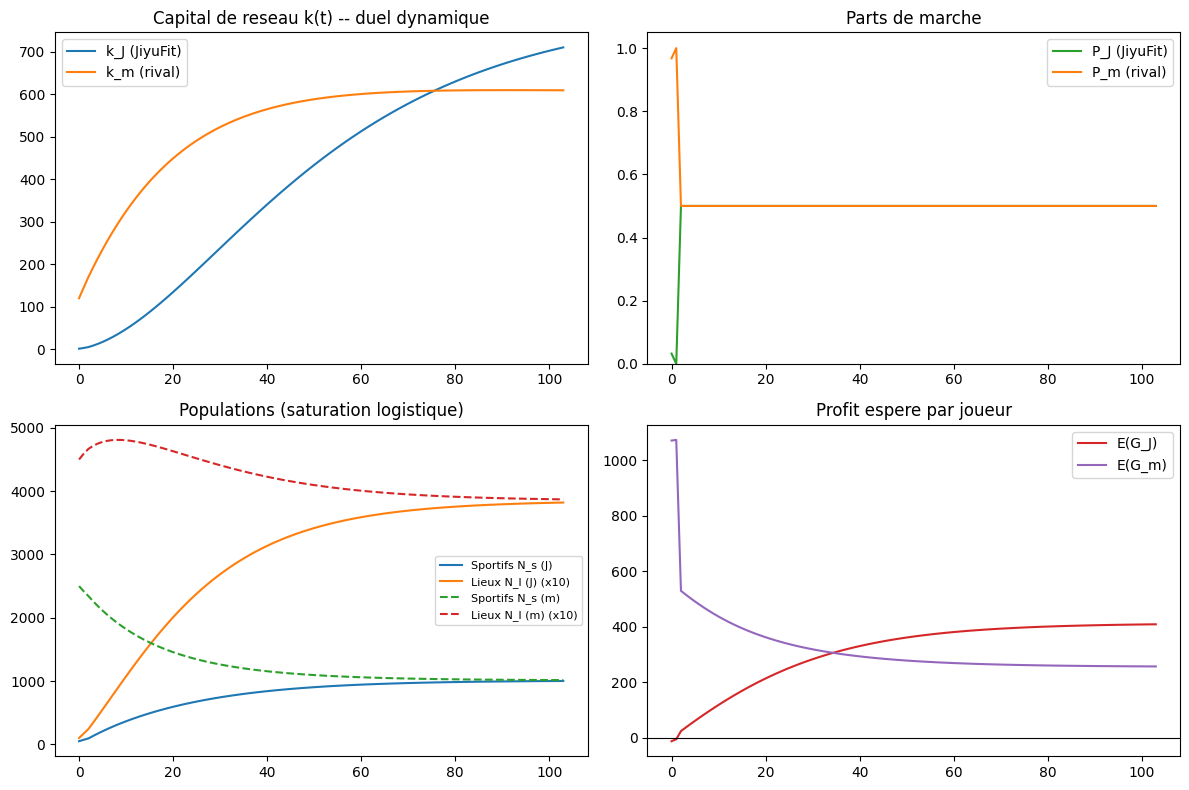

Periode finale : P_J=0.500, P_m=0.500, k_J=710.7, k_m=609.6, profit_J=409.03, profit_m=257.23
Bascule concurrentielle (P_J > P_m) a la periode t = 0


In [119]:
params = ModelParams()
T = 104  # ~ 2 ans en semaines

# Rival modelise comme un INCUMBENT installe : il demarre avec un fort capital
# de reseau et des populations dejà acquises. JiyuFit est le challengeur.
hist = simulate(params, T=T,
                k_J0=1.0,   k_m0=120.0,          # capital initial : rival dominant
                x_J0=8.0,   x_m0=2.0,            # JiyuFit investit fort pour entrer
                Ns0=50.0,   Nl0=10.0,           # JiyuFit part de presque rien
                Ns_m0=2500.0, Nl_m0=450.0,      # rival a dejà une large base
                quality_s=0.75, quality_l=0.75, # meilleure qualite d'engagement (J)
                quality_s_m=0.55, quality_l_m=0.55,
                rival_reactive=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(hist['k_J'], label='k_J (JiyuFit)')
axes[0, 0].plot(hist['k_m'], label='k_m (rival)')
axes[0, 0].set_title("Capital de reseau k(t) -- duel dynamique")
axes[0, 0].legend()

axes[0, 1].plot(hist['P_J'], color='tab:green', label='P_J (JiyuFit)')
axes[0, 1].plot(hist['P_m'], color='tab:orange', label='P_m (rival)')
axes[0, 1].set_title("Parts de marche")
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].legend()

axes[1, 0].plot(hist['Ns'], label='Sportifs N_s (J)')
axes[1, 0].plot(hist['Nl'] * 10, label='Lieux N_l (J) (x10)')
axes[1, 0].plot(hist['Ns_m'], '--', label='Sportifs N_s (m)')
axes[1, 0].plot(hist['Nl_m'] * 10, '--', label='Lieux N_l (m) (x10)')
axes[1, 0].set_title("Populations (saturation logistique)")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(hist['profit'], color='tab:red', label='E(G_J)')
axes[1, 1].plot(hist['profit_m'], color='tab:purple', label='E(G_m)')
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title("Profit espere par joueur")
axes[1, 1].legend()

plt.tight_layout()
plt.show()
print(f"Periode finale : P_J={hist['P_J'][-1]:.3f}, P_m={hist['P_m'][-1]:.3f}, "
      f"k_J={hist['k_J'][-1]:.1f}, k_m={hist['k_m'][-1]:.1f}, "
      f"profit_J={hist['profit'][-1]:.2f}, profit_m={hist['profit_m'][-1]:.2f}")

# Periode de bascule : premier t ou JiyuFit depasse le rival en part de marche
cross = np.argmax(hist['P_J'] > hist['P_m'])
print(f"Bascule concurrentielle (P_J > P_m) a la periode t = {cross}")

In [120]:
# Verification numerique de la Section X.3 : limite d'asymetrie radicale
# quand k_J -> infini, x_J* -> 0 mais P_J -> 1 (cf. Section V.3)
e_m_fixed = 5.0 * 1.0   # k_m * x_m fixe
V_J_fixed = value_function(effective_population(200, 0.7),
                            effective_population(30, 0.7), 200, 30, params)

k_J_values = np.array([1, 10, 1e2, 1e3, 1e4, 1e5, 1e6, 1e8, 1e10])
x_J_star = np.array([best_response(k, e_m_fixed, V_J_fixed) for k in k_J_values])
P_J_star = np.array([
    capture_probability([k, 5.0], [x, 1.0], r=params.r)[0]
    for k, x in zip(k_J_values, x_J_star)
])

for k, x, pj in zip(k_J_values, x_J_star, P_J_star):
    print(f"k_J={k:.0e}  ->  x_J*={x:.6f}   P_J={pj:.6f}")

print("Conclusion : x_J* -> 0 tandis que P_J -> 1, conformement a la Section V.3.")

k_J=1e+00  ->  x_J*=17.523765   P_J=0.778012
k_J=1e+01  ->  x_J*=6.622640   P_J=0.929801
k_J=1e+02  ->  x_J*=2.202377   P_J=0.977801
k_J=1e+03  ->  x_J*=0.707264   P_J=0.992980
k_J=1e+04  ->  x_J*=0.224738   P_J=0.997780
k_J=1e+05  ->  x_J*=0.071176   P_J=0.999298
k_J=1e+06  ->  x_J*=0.022519   P_J=0.999778
k_J=1e+08  ->  x_J*=0.002252   P_J=0.999978
k_J=1e+10  ->  x_J*=0.000225   P_J=0.999998
Conclusion : x_J* -> 0 tandis que P_J -> 1, conformement a la Section V.3.


Coherence de la condition de bascule verifiee sur 103/103 periodes.


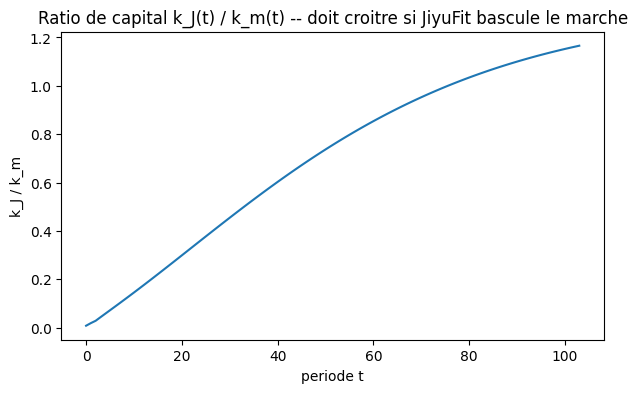

In [121]:
# Verification numerique de la condition de bascule (Section VIII.1 / X.4)
# On verifie que Delta k_J / k_J > Delta k_m / k_m implique un ratio croissant
ratio = hist['k_J'] / hist['k_m']
growth_J = np.diff(hist['k_J']) / hist['k_J'][:-1]
growth_m = np.diff(hist['k_m']) / hist['k_m'][:-1]
bascule_ok = (growth_J > growth_m) == (np.diff(ratio) > 0)

print(f"Coherence de la condition de bascule verifiee sur {bascule_ok.sum()}/{len(bascule_ok)} periodes.")

plt.figure(figsize=(7, 4))
plt.plot(ratio)
plt.title("Ratio de capital k_J(t) / k_m(t) -- doit croitre si JiyuFit bascule le marche")
plt.xlabel("periode t")
plt.ylabel("k_J / k_m")
plt.show()

## XII. Tests automatiques (assertions)

Cette section regroupe une batterie de **tests automatiques** exécutables (`assert`) qui vérifient les invariants structurels du modèle sur la trajectoire simulée `hist`. Ils servent de garde-fou : si une modification future casse une propriété fondamentale (fermeture de la loi de capture, positivité de l'effort, bornes des parts de marché, plafonnement logistique des populations), un test échouera immédiatement. Chaque bloc reprend un résultat démontré dans la Section X.

In [122]:
# =====================================================================
# XII. TESTS AUTOMATIQUES  --  invariants structurels du modele JiyuFit
# Executer APRES la cellule de simulation (variables hist, params, T,
# et les fonctions capture_probability / best_response / value_function
# doivent etre definies). Chaque assert protege une propriete demontree
# en Section X. Si tout passe, le message final s'affiche.
# =====================================================================

import numpy as np

TOL = 1e-9
p = params

# --- Test 1 : fermeture de la loi de capture de Tullock (Section X.5)
#     Pour tout etat (k, x) non nul, sum_i P_i = 1.
for _ in range(1000):
    k = np.random.default_rng(_).uniform(0.1, 500, size=2)
    x = np.random.default_rng(1000 + _).uniform(0.0, 50, size=2)
    P = capture_probability(k, x, r=p.r)
    assert abs(P.sum() - 1.0) < TOL, f"sum(P)={P.sum()} != 1 pour k={k}, x={x}"
# Cas degenere : efforts tous nuls -> repartition uniforme 1/n (convention).
P0 = capture_probability([10.0, 3.0], [0.0, 0.0], r=p.r)
assert abs(P0.sum() - 1.0) < TOL and np.allclose(P0, 0.5), "cas 0/0 mal gere"
print("Test 1 OK : sum(P) == 1 (loi de capture bien normalisee).")

# --- Test 2 : effort optimal x*  (Section X.1 / X.2)
# 2a. Defense du domaine : x* == 0 des que k_J <= 0, e_m <= 0 ou V_J <= 0.
assert best_response(0.0, 10.0, 100.0) == 0.0, "x* != 0 pour k_J = 0"
assert best_response(-1.0, 10.0, 100.0) == 0.0, "x* != 0 pour k_J < 0"
assert best_response(5.0, 0.0, 100.0) == 0.0, "x* != 0 pour e_m = 0"
assert best_response(5.0, 10.0, 0.0) == 0.0, "x* != 0 pour V_J = 0"
# 2b. Positivite : x* >= 0 sur des tirages aleatoires quelconques.
for _ in range(1000):
    rng = np.random.default_rng(2000 + _)
    k_J = rng.uniform(0.1, 1000)
    e_m = rng.uniform(0.0, 500)
    V_J = rng.uniform(-50, 500)
    x_star = best_response(k_J, e_m, V_J)
    assert x_star >= 0.0, f"x_star={x_star} < 0 pour k_J={k_J}, e_m={e_m}, V_J={V_J}"
# 2c. OPTIMALITE : quand la solution est interieure (x* > 0), la condition
#     du premier ordre  k_J * e_m * V_J / (k_J*x* + e_m)^2 == 1  doit tenir.
#     C'est le vrai test que best_response resout bien l'equation de Nash.
for seed in range(1000):
    rng = np.random.default_rng(3000 + seed)
    k_J = rng.uniform(0.1, 1000.0)
    e_m = rng.uniform(0.1, 500.0)
    V_J = rng.uniform(0.1, 1000.0)
    x_star = best_response(k_J, e_m, V_J)
    if x_star > TOL:
        foc = k_J * e_m * V_J / (k_J * x_star + e_m) ** 2
        assert np.isclose(foc, 1.0, rtol=1e-8, atol=1e-8), (
            f"CPO non satisfaite : foc={foc} pour k_J={k_J}, e_m={e_m}, V_J={V_J}")
print("Test 2 OK : x* >= 0, domaine defendu, et condition du premier ordre verifiee.")

# --- Test 2bis : meilleure reponse NUMERIQUE pour r != 1 (Section V generalisee)
# La CPO generale k_J * V_J * r * e_J^(r-1) * e_m^r / (e_J^r + e_m^r)^2 = 1 doit
# tenir a la solution interieure, pour plusieurs valeurs de r.
def _foc_check(x_star, k_J, e_m, V_J, r):
    e_J = k_J * x_star
    return k_J * V_J * r * e_J ** (r - 1.0) * e_m ** r / (e_J ** r + e_m ** r) ** 2

for r_test in [0.5, 0.8, 1.5, 2.0, 3.0]:
    n_interior = 0
    for seed in range(300):
        rng = np.random.default_rng(4000 + seed)
        k_J = rng.uniform(0.1, 1000.0)
        e_m = rng.uniform(0.1, 500.0)
        V_J = rng.uniform(0.1, 1000.0)
        x_star = best_response(k_J, e_m, V_J, r=r_test)
        assert x_star >= 0.0, f"x* < 0 pour r={r_test}"
        if x_star > TOL:
            foc = _foc_check(x_star, k_J, e_m, V_J, r_test)
            assert np.isclose(foc, 1.0, rtol=1e-6, atol=1e-6), (
                f"CPO generale non satisfaite : foc={foc}, r={r_test}")
            n_interior += 1
    assert n_interior > 0, f"aucune solution interieure trouvee pour r={r_test}"

# Non-regression : pour r = 1, la voie numerique et la formule fermee coincident.
for seed in range(300):
    rng = np.random.default_rng(5000 + seed)
    k_J = rng.uniform(0.1, 1000.0)
    e_m = rng.uniform(0.1, 500.0)
    V_J = rng.uniform(0.1, 1000.0)
    analytique = best_response(k_J, e_m, V_J, r=1.0)
    numerique  = best_response(k_J, e_m, V_J, r=1.0000001)  # force la branche numerique
    assert np.isclose(analytique, numerique, rtol=1e-3, atol=1e-3), (
        f"ecart analytique/numerique a r~1 : {analytique} vs {numerique}")
print("Test 2bis OK : best_response numerique valide pour r in {0.5,0.8,1.5,2,3} "
      "et coherent avec la formule fermee a r = 1.")

# --- Test 3 : bornes des parts de marche 0 <= P_J <= 1 sur la trajectoire
assert np.all(hist['P_J'] >= -TOL) and np.all(hist['P_J'] <= 1.0 + TOL), "P_J hors [0,1]"
assert np.all(hist['P_m'] >= -TOL) and np.all(hist['P_m'] <= 1.0 + TOL), "P_m hors [0,1]"
assert np.allclose(hist['P_J'] + hist['P_m'], 1.0, atol=TOL), "P_J + P_m != 1"
print("Test 3 OK : 0 <= P_J, P_m <= 1 et P_J + P_m == 1 a chaque periode.")

# --- Test 4 : plafonnement logistique et non-negativite des populations
#     (Section X.6.a) -- pour JiyuFit ET pour le rival.
assert np.all(hist['Ns']   <= p.K_s + TOL), "N_s (JiyuFit) depasse K_s"
assert np.all(hist['Ns_m'] <= p.K_s + TOL), "N_s (rival) depasse K_s"
assert np.all(hist['Nl']   <= p.K_l + TOL), "N_l (JiyuFit) depasse K_l"
assert np.all(hist['Nl_m'] <= p.K_l + TOL), "N_l (rival) depasse K_l"
for key in ['Ns', 'Nl', 'Ns_m', 'Nl_m']:
    assert np.all(hist[key] >= -TOL), f"{key} contient une population negative"
print(f"Test 4 OK : populations bornees (N_s <= K_s={p.K_s:.0f}, N_l <= K_l={p.K_l:.0f}) "
      "et non negatives, pour JiyuFit et le rival.")

# --- Test 5 : coherence de la condition de bascule (Section X.4)
#     signe(Delta(k_J/k_m)) == signe(growth_J - growth_m).
ratio    = hist['k_J'] / hist['k_m']
growth_J = np.diff(hist['k_J']) / hist['k_J'][:-1]
growth_m = np.diff(hist['k_m']) / hist['k_m'][:-1]
assert np.all((growth_J > growth_m) == (np.diff(ratio) > 0)), "condition de bascule violee"
print("Test 5 OK : condition de bascule coherente sur toute la trajectoire.")

# --- Test 6 : capital de reseau strictement positif (plancher 1e-6)
assert np.all(hist['k_J'] > 0) and np.all(hist['k_m'] > 0), "capital <= 0"
print("Test 6 OK : capital de reseau strictement positif.")

# --- Test 7 : aucune valeur non finie (NaN / inf) dans toute la trajectoire.
#     Un modele peut respecter des bornes tout en ayant produit un NaN ailleurs.
for key, values in hist.items():
    assert np.all(np.isfinite(values)), f"{key} contient NaN ou inf"
print("Test 7 OK : toutes les series de hist sont finies (aucun NaN ni inf).")

print("\n[OK] Tous les tests automatiques ont reussi.")

Test 1 OK : sum(P) == 1 (loi de capture bien normalisee).
Test 2 OK : x* >= 0, domaine defendu, et condition du premier ordre verifiee.
Test 2bis OK : best_response numerique valide pour r in {0.5,0.8,1.5,2,3} et coherent avec la formule fermee a r = 1.
Test 3 OK : 0 <= P_J, P_m <= 1 et P_J + P_m == 1 a chaque periode.
Test 4 OK : populations bornees (N_s <= K_s=5000, N_l <= K_l=800) et non negatives, pour JiyuFit et le rival.
Test 5 OK : condition de bascule coherente sur toute la trajectoire.
Test 6 OK : capital de reseau strictement positif.
Test 7 OK : toutes les series de hist sont finies (aucun NaN ni inf).

[OK] Tous les tests automatiques ont reussi.


## XIII. Équilibre de Nash simultané (recherche directe, indépendante de la dynamique)

**Distinction fondamentale.** La section XI simule une *dynamique adaptative* : à chaque pas de temps, chaque acteur joue sa meilleure réponse à l'état courant de l'adversaire (tâtonnement séquentiel). Cette dynamique n'est **pas** la définition d'un équilibre de Nash.

Un **équilibre de Nash simultané** est un profil d'efforts $(x_J^\*, x_m^\*)$ tel que *chacun* joue simultanément sa meilleure réponse à l'autre. C'est, par définition, un **point fixe de l'application de meilleure réponse jointe** :

$$x_J^\* = \mathrm{BR}_J\big(k_m\, x_m^\*\big), \qquad x_m^\* = \mathrm{BR}_m\big(k_J\, x_J^\*\big).$$

où `best_response(k, e_rival, V, r)` renvoie l'effort brut optimal et `e_rival` est l'effort *effectif* de l'adversaire.

**Ce que fait cette section (et ce qu'elle ne fait pas).** On recherche ici les points fixes $(x_J^\*, x_m^\*)$ **directement**, par résolution du système $x = \mathrm{BR}(x)$, sans aucune notion de temps ni de trajectoire. La convergence de la dynamique adaptative vers ces points fixes, et leur stabilité, seront traitées séparément dans une section ultérieure. On garde donc strictement séparées les deux notions : *équilibre* (point fixe, ici) et *dynamique* (trajectoire, section XI).

In [123]:
# =====================================================================
# XIII. EQUILIBRE DE NASH SIMULTANE  --  recherche directe (point fixe)
# ---------------------------------------------------------------------
# IMPORTANT : cette section ne contient AUCUNE dynamique temporelle.
# Un equilibre de Nash est defini ici comme un point fixe de
# l'application de meilleure reponse jointe. La convergence de la
# dynamique adaptative (Section XI) vers ces points fixes, et leur
# stabilite, sont traitees separement (section ulterieure).
# =====================================================================
from scipy.optimize import fsolve

def joint_best_response(x, k_J, k_m, V_J, V_m, r=1.0):
    """Application de meilleure reponse JOINTE (simultanee).

    Entree : x = (x_J, x_m) efforts BRUTS des deux acteurs.
    Sortie : (BR_J, BR_m) ou chaque acteur repond a l'effort EFFECTIF
             (k * x) de l'adversaire. Aucune notion de temps ici.
    """
    x_J, x_m = x
    br_J = best_response(k_J, k_m * x_m, V_J, r=r)
    br_m = best_response(k_m, k_J * x_J, V_m, r=r)
    return np.array([br_J, br_m], dtype=float)

def nash_residual(x, k_J, k_m, V_J, V_m, r=1.0):
    """Residu du systeme de point fixe : x - BR(x). Nul a l'equilibre."""
    return np.asarray(x, dtype=float) - joint_best_response(x, k_J, k_m, V_J, V_m, r=r)

def find_nash_equilibrium(k_J, k_m, V_J, V_m, r=1.0,
                          n_starts=25, tol=1e-9, seed=0):
    """Recherche DIRECTE d'un equilibre de Nash comme point fixe de la
    meilleure reponse jointe (multi-start pour la robustesse).

    Renvoie (x_star, info) ou x_star = (x_J*, x_m*) et info contient
    le residu et le nombre de departs ayant converge vers ce point.
    """
    rng_local = np.random.default_rng(seed)
    # Echelle des efforts : ~ V (et NON V/k). Pour r = 1, le point fixe
    # interieur symetrique vaut x* = V/4 (independant de k). Des departs en
    # V/k sous-estiment grossierement l'echelle quand k >> 1 et rabattent
    # fsolve sur le seul point trivial (0, 0). On balaie donc large en ~ V,
    # avec un melange d'echelles pour capter aussi les regimes asymetriques.
    scale = np.array([V_J, V_m], dtype=float)
    starts = [np.array([0.0, 0.0])]
    for _ in range(n_starts):
        starts.append(rng_local.uniform(0.0, 1.0, size=2) * scale)
        starts.append(rng_local.uniform(0.0, 0.5, size=2) * scale)  # depart median

    solutions = []
    for x0 in starts:
        sol, infodict, ier, msg = fsolve(
            nash_residual, x0, args=(k_J, k_m, V_J, V_m, r),
            full_output=True, xtol=1e-12)
        if ier != 1:
            continue
        sol = np.maximum(sol, 0.0)  # efforts non negatifs
        res = np.linalg.norm(nash_residual(sol, k_J, k_m, V_J, V_m, r=r))
        if res < tol:
            solutions.append(sol)

    if not solutions:
        raise RuntimeError("Aucun point fixe trouve (essayez d'autres departs).")

    # regrouper les solutions distinctes (a tolerance pres)
    uniques = []
    for s in solutions:
        if not any(np.allclose(s, u, atol=1e-6) for u in uniques):
            uniques.append(s)

    # Plusieurs points fixes peuvent coexister : le profil trivial (0, 0)
    # est toujours un equilibre degenere (personne n'investit). On distingue
    # l'equilibre INTERIEUR (efforts strictement positifs), economiquement
    # pertinent, du point fixe trivial.
    uniques.sort(key=lambda u: -np.linalg.norm(u))  # interieurs d'abord
    interieurs = [u for u in uniques if np.all(u > 1e-9)]
    triviaux = [u for u in uniques if not np.all(u > 1e-9)]
    x_star = interieurs[0] if interieurs else uniques[0]
    info = {
        "residu": float(np.linalg.norm(nash_residual(x_star, k_J, k_m, V_J, V_m, r=r))),
        "n_points_fixes_distincts": len(uniques),
        "points_fixes": [tuple(u) for u in uniques],
        "equilibre_interieur": x_star if interieurs else None,
        "equilibre_trivial": triviaux[0] if triviaux else None,
    }
    return x_star, info


# --- Application au calibrage JiyuFit vs rival symetrique -------------
params = ModelParams()

# Primitives de capture : intensite d'effort k et valeur capturable V
# pour chacun des deux acteurs. On prend un rival de meme valeur (V_m = V_J)
# mais on laisse k_J, k_m potentiellement asymetriques.
k_J, k_m = 1.0, 1.0
V_J = V_m = 1000.0

x_star, info = find_nash_equilibrium(k_J, k_m, V_J, V_m, r=params.r)

print("=== Equilibre de Nash simultane (points fixes de la meilleure reponse) ===")
print(f"nombre de points fixes distincts detectes : {info['n_points_fixes_distincts']}")
if info['equilibre_trivial'] is not None:
    t = info['equilibre_trivial']
    print(f"  - equilibre TRIVIAL   : x_J*={t[0]:.4f}, x_m*={t[1]:.4f}  (personne n'investit)")
print(f"  - equilibre INTERIEUR : x_J*={x_star[0]:.6f}, x_m*={x_star[1]:.6f}  (retenu)")
print(f"residu ||x - BR(x)|| au point interieur = {info['residu']:.2e}")

# Probabilites de capture a l'equilibre
P = capture_probability([k_J, k_m], [x_star[0], x_star[1]], r=params.r)
print(f"P_J* = {P[0]:.4f}   P_m* = {P[1]:.4f}")

# --- Verification que c'est bien un equilibre de Nash ----------------
# 1) c'est un point fixe : x* == BR(x*)
br = joint_best_response(x_star, k_J, k_m, V_J, V_m, r=params.r)
assert np.allclose(x_star, br, atol=1e-6), "x* n'est pas un point fixe de BR"

# 2) symetrie : k_J == k_m et V_J == V_m => x_J* == x_m*
assert np.isclose(x_star[0], x_star[1], atol=1e-6), (
    "cas symetrique : les efforts d'equilibre devraient etre egaux")

# 3) au cas symetrique r=1, la valeur theorique du point fixe interieur est
#    x* = V/4, INDEPENDANT de k. En effort BRUT symetrique x, la meilleure
#    reponse s'ecrit BR(x) = sqrt(x V) - x ; le point fixe interieur BR(x) = x
#    donne 2x = sqrt(x V), soit x* = V/4. (La forme V/(4k) parfois citee n'est
#    valable qu'au cas particulier k = 1, ou V/4 = V/(4k).)
x_theo = V_J / 4.0  # valeur fermee du point fixe symetrique pour r = 1
if np.isclose(params.r, 1.0):
    assert np.isclose(x_star[0], x_theo, rtol=1e-6), (
        f"x_J*={x_star[0]} != valeur theorique {x_theo}")

print("\n[OK] XIII : l'equilibre trouve est bien un point fixe de la meilleure")
print("     reponse jointe (equilibre de Nash), distinct de toute dynamique.")

=== Equilibre de Nash simultane (points fixes de la meilleure reponse) ===
nombre de points fixes distincts detectes : 2
  - equilibre TRIVIAL   : x_J*=0.0000, x_m*=0.0000  (personne n'investit)
  - equilibre INTERIEUR : x_J*=250.000000, x_m*=250.000000  (retenu)
residu ||x - BR(x)|| au point interieur = 4.02e-14
P_J* = 0.5000   P_m* = 0.5000

[OK] XIII : l'equilibre trouve est bien un point fixe de la meilleure
     reponse jointe (equilibre de Nash), distinct de toute dynamique.


## XIV. Stabilité des équilibres et convergence de la dynamique adaptative

Après avoir identifié les équilibres (section XIII) *indépendamment* de toute dynamique, on étudie ici **deux questions distinctes** :

**1. Stabilité locale (propriété statique de chaque point fixe).** La dynamique de meilleure réponse s'écrit $x_{t+1} = \mathrm{BR}(x_t)$. Un point fixe $x^\*$ est **localement stable** si le rayon spectral du jacobien $J = \partial \mathrm{BR}/\partial x$ évalué en $x^\*$ vérifie $\rho(J) < 1$ (théorème de la contraction locale) ; il est **instable** si $\rho(J) > 1$. On calcule $J$ par différences finies et on classe chacun des deux points fixes.

**2. Convergence effective (propriété de la trajectoire).** On itère la dynamique de meilleure réponse à *primitives fixes* $(k_J, k_m, V_J, V_m, r)$ — exactement les mêmes que la section XIII — depuis plusieurs conditions initiales, et l'on vérifie numériquement où elle aboutit.

**Attention à la portée du test.** On teste ici la dynamique de meilleure réponse *sur les seuls efforts, à valeur $V$ constante*. C'est l'objet directement comparable à l'équilibre de Nash statique. La fonction `simulate` de la Section XI est un objet plus riche (populations, capital de réseau, $V$ endogène qui évolue dans le temps) : son régime permanent ne coïncide pas mécaniquement avec cet équilibre à $V$ figé, et sa validation relève d'une étude séparée. On garde donc, ici encore, les notions bien distinctes : *stabilité d'un point fixe* et *convergence d'une trajectoire d'efforts* d'un côté, *dynamique écosystémique complète* de l'autre.

In [124]:
# =====================================================================
# XIV. STABILITE DES EQUILIBRES ET CONVERGENCE DE LA DYNAMIQUE
# ---------------------------------------------------------------------
# On distingue deux objets :
#   (A) STABILITE LOCALE : propriete statique d'un point fixe, via le
#       rayon spectral du jacobien de la meilleure reponse BR en ce point.
#   (B) CONVERGENCE : propriete d'une trajectoire de meilleure reponse
#       x_{t+1} = BR(x_t), a primitives (k, V, r) FIXES.
# La dynamique ecosystemique complete (Section XI, V endogene) est un
# objet distinct, non teste ici.
# =====================================================================

def br_jacobian(x_fixed, k_J, k_m, V_J, V_m, r=1.0, h=1e-5):
    """Jacobien de l'application de meilleure reponse jointe BR au point
    x_fixed, par differences finies centrees. J[i, j] = d BR_i / d x_j."""
    x_fixed = np.asarray(x_fixed, dtype=float)
    n = x_fixed.size
    J = np.zeros((n, n))
    for j in range(n):
        step = h * max(1.0, abs(x_fixed[j]))
        xp = x_fixed.copy(); xp[j] += step
        xm = x_fixed.copy(); xm[j] -= step
        br_p = joint_best_response(xp, k_J, k_m, V_J, V_m, r=r)
        br_m = joint_best_response(xm, k_J, k_m, V_J, V_m, r=r)
        J[:, j] = (br_p - br_m) / (2.0 * step)
    return J

def spectral_radius(M):
    """Rayon spectral (plus grand module de valeur propre)."""
    return float(np.max(np.abs(np.linalg.eigvals(M))))

def classify_fixed_point(x_fixed, k_J, k_m, V_J, V_m, r=1.0):
    """Classe un point fixe : stable si rho(J) < 1, instable si rho(J) > 1."""
    J = br_jacobian(x_fixed, k_J, k_m, V_J, V_m, r=r)
    rho = spectral_radius(J)
    statut = "stable" if rho < 1.0 - 1e-6 else ("instable" if rho > 1.0 + 1e-6 else "marginal")
    return rho, statut, J

def best_response_dynamics(x0, k_J, k_m, V_J, V_m, r=1.0,
                           n_iter=500, tol=1e-10):
    """Dynamique de meilleure reponse SIMULTANEE a primitives fixes :
    x_{t+1} = BR(x_t). Renvoie la trajectoire et le point limite.
    Aucune population ni capital de reseau : uniquement les efforts."""
    x = np.asarray(x0, dtype=float)
    traj = [x.copy()]
    for _ in range(n_iter):
        x_next = joint_best_response(x, k_J, k_m, V_J, V_m, r=r)
        traj.append(x_next.copy())
        if np.linalg.norm(x_next - x) < tol:
            x = x_next
            break
        x = x_next
    return np.array(traj), x


# --- (A) Classification des deux equilibres de la Section XIII --------
print("=== (A) Stabilite locale des points fixes (rayon spectral de J_BR) ===")
x_triv = np.array([0.0, 0.0])
rho_int, stat_int, J_int = classify_fixed_point(x_star, k_J, k_m, V_J, V_m, r=params.r)
rho_tri, stat_tri, J_tri = classify_fixed_point(x_triv,  k_J, k_m, V_J, V_m, r=params.r)
print(f"  equilibre INTERIEUR (x*={x_star[0]:.1f}, {x_star[1]:.1f}) : rho(J)={rho_int:.4f} -> {stat_int}")
print(f"  equilibre TRIVIAL   (x*=0, 0)          : rho(J)={rho_tri:.4f} -> {stat_tri}")

# --- (B) Convergence de la dynamique de meilleure reponse ------------
# La dynamique de meilleure reponse n'est PAS globalement convergente :
# l'equilibre interieur est localement stable mais son bassin est borne.
# Un choc symetrique tres grand peut faire s'effondrer le systeme vers le
# point trivial (best_response a un rival tres fort = 0). On classe donc
# l'aboutissement selon le point de depart, sans imposer une convergence
# globale qui serait fausse.
def _classer_limite(x_inf):
    if np.allclose(x_inf, x_star, atol=1e-4):
        return "-> INTERIEUR"
    if np.allclose(x_inf, [0.0, 0.0], atol=1e-4):
        return "-> TRIVIAL (effondrement)"
    return "-> autre / non convergent"

print("\n=== (B) Convergence de la dynamique x_{t+1} = BR(x_t) ===")
starts = [
    np.array([1.0, 1.0]),
    np.array([500.0, 10.0]),
    np.array([10.0, 500.0]),
    np.array([200.0, 300.0]),
    np.array([1000.0, 1000.0]),
    np.array([0.01, 0.01]),
]
for x0 in starts:
    traj, x_inf = best_response_dynamics(x0, k_J, k_m, V_J, V_m, r=params.r)
    print(f"  depart {str(x0):>22} -> limite ({x_inf[0]:8.3f}, {x_inf[1]:8.3f}) "
          f"en {len(traj)-1:3d} iter  {_classer_limite(x_inf)}")


# --- Verifications ---------------------------------------------------
# 1) L'equilibre interieur est localement stable, le trivial instable.
assert rho_int < 1.0, f"equilibre interieur non stable : rho={rho_int}"
assert rho_tri > 1.0, f"equilibre trivial devrait etre instable : rho={rho_tri}"

# 2) Stabilite LOCALE effective : depuis un voisinage de l'equilibre
#    interieur, la dynamique y revient (bassin d'attraction non vide).
rng_bas = np.random.default_rng(7)
for _ in range(20):
    x0 = x_star * (1.0 + rng_bas.uniform(-0.3, 0.3, size=2))  # +/-30 %
    _, x_inf = best_response_dynamics(x0, k_J, k_m, V_J, V_m, r=params.r)
    assert np.allclose(x_inf, x_star, atol=1e-4), (
        f"pas de retour a l'interieur depuis {x0} : limite={x_inf}")

# 3) COHERENCE dynamique <-> equilibre : quand la dynamique converge vers
#    l'interieur, son point limite est bien un point fixe (residu nul) et
#    coincide avec la recherche directe de la Section XIII.
_, x_inf = best_response_dynamics(np.array([200.0, 300.0]),
                                  k_J, k_m, V_J, V_m, r=params.r)
res_inf = np.linalg.norm(nash_residual(x_inf, k_J, k_m, V_J, V_m, r=params.r))
assert res_inf < 1e-8, f"le point limite n'est pas un point fixe : residu={res_inf}"
assert np.allclose(x_inf, x_star, atol=1e-4), "dynamique et Nash direct divergent"

print("\n[OK] XIV : equilibre interieur STABLE (rho<1), trivial INSTABLE (rho>1).")
print("     Depuis un voisinage de l'interieur, la dynamique de meilleure reponse y")
print("     revient et son point limite coincide avec le Nash direct (coherence).")
print("     NB : la convergence n'est PAS globale (bassin borne) ; un choc symetrique")
print("     tres grand peut faire s'effondrer le systeme vers l'equilibre trivial.")

=== (A) Stabilite locale des points fixes (rayon spectral de J_BR) ===
  equilibre INTERIEUR (x*=250.0, 250.0) : rho(J)=0.0000 -> stable
  equilibre TRIVIAL   (x*=0, 0)          : rho(J)=4999.5000 -> instable

=== (B) Convergence de la dynamique x_{t+1} = BR(x_t) ===
  depart                [1. 1.] -> limite ( 250.000,  250.000) en   7 iter  -> INTERIEUR
  depart            [500.  10.] -> limite ( 250.000,  250.000) en   7 iter  -> INTERIEUR
  depart            [ 10. 500.] -> limite ( 250.000,  250.000) en   7 iter  -> INTERIEUR
  depart            [200. 300.] -> limite ( 250.000,  250.000) en   5 iter  -> INTERIEUR
  depart          [1000. 1000.] -> limite (   0.000,    0.000) en   2 iter  -> TRIVIAL (effondrement)
  depart            [0.01 0.01] -> limite ( 250.000,  250.000) en   8 iter  -> INTERIEUR

[OK] XIV : equilibre interieur STABLE (rho<1), trivial INSTABLE (rho>1).
     Depuis un voisinage de l'interieur, la dynamique de meilleure reponse y
     revient et son point limite c

## XV. Cohérence entre le régime permanent de `simulate(...)` et l'équilibre de Nash

Les sections XIII et XIV raisonnent à **primitives figées** $(k_J, k_m, V_J, V_m, r)$ : l'équilibre intérieur $x^\* = 250$ y est calculé pour $k=1$, $V=1000$. La fonction `simulate(...)` de la section XI est un objet **plus riche** : le capital de réseau $k(t)$ s'accumule et les populations bifaces évoluent, de sorte que $V(t)$ est **endogène**. Son régime permanent n'a donc aucune raison de tomber sur $(250, 250)$ — il converge vers un point fixe du système *complet* où $k$ et $V$ se sont eux aussi stabilisés.

**Le bon test de cohérence** n'est pas « `simulate` converge-t-il vers 250 ? », mais : *au régime permanent de `simulate`, les efforts observés sont-ils une meilleure réponse mutuelle, compte tenu des $k$ et $V$ stationnaires atteints ?* Autrement dit, on vérifie l'auto-cohérence

$$\big\lVert\, x_\infty - \mathrm{BR}(x_\infty;\, k_\infty, V_\infty)\,\big\rVert \approx 0,$$

et l'on confirme que $x_\infty$ coïncide avec l'équilibre intérieur retourné par `find_nash_equilibrium` **évalué aux primitives stationnaires** $(k_\infty, V_\infty)$. On ajoute enfin un garde de non-régression : au cas dégénéré symétrique $k=1$, $V=1000$, la recherche directe redonne exactement $250$ (lien avec la section XIII).

In [125]:
# =====================================================================
# XV. COHERENCE : REGIME PERMANENT DE simulate(...) <-> EQUILIBRE DE NASH
# ---------------------------------------------------------------------
# Objet du test : relier enfin les deux mondes.
#   - Sections XIII/XIV : equilibre a PRIMITIVES FIGEES (k=1, V=1000 -> x*=250).
#   - Section XI (simulate) : dynamique ECOSYSTEMIQUE complete, ou k(t) et
#     V(t) sont ENDOGENES. Son regime permanent n'a aucune raison de valoir
#     250 ; il converge vers un point fixe du systeme complet.
#
# Le bon critere n'est donc PAS "simulate -> 250" mais l'AUTO-COHERENCE :
# au regime permanent, les efforts observes sont-ils une meilleure reponse
# mutuelle, compte tenu des k et V STATIONNAIRES reellement atteints ?
#       || x_inf - BR(x_inf ; k_inf, V_inf) ||  ~  0
# puis on confirme que x_inf coincide avec find_nash_equilibrium EVALUE
# a ces primitives stationnaires.
# =====================================================================
import numpy as np

def _regime_permanent(hist, fenetre=10, rtol=1e-3):
    """Detecte un regime quasi-permanent en fin de trajectoire : on exige que
    les series cles (k_J, k_m, x_J, x_m, V_J, V_m) varient de moins de rtol
    (en relatif) sur les 'fenetre' dernieres periodes. Renvoie les valeurs
    stationnaires moyennees sur la fenetre et un indicateur de stabilite."""
    cles = ['k_J', 'k_m', 'x_J', 'x_m', 'V_J', 'V_m']
    stable = True
    vals = {}
    for c in cles:
        serie = np.asarray(hist[c])[-fenetre:]
        vals[c] = float(np.mean(serie))
        ref = abs(vals[c]) + 1e-12
        variation = (serie.max() - serie.min()) / ref
        if variation > rtol:
            stable = False
    return vals, stable

# --- 1) On rejoue la dynamique complete jusqu'a un regime permanent ---------
params = ModelParams()
T_long = 2000  # horizon long pour laisser k et V se stabiliser
hist_lp = simulate(params, T=T_long,
                   k_J0=1.0, k_m0=1.0,        # cas symetrique : primitives
                   x_J0=1.0, x_m0=1.0,        # initiales egales cote J et m
                   Ns0=50.0, Nl0=10.0,
                   Ns_m0=50.0, Nl_m0=10.0,
                   quality_s=0.7, quality_l=0.7,
                   quality_s_m=0.7, quality_l_m=0.7,
                   rival_reactive=True)

vals, stable = _regime_permanent(hist_lp, fenetre=20, rtol=1e-3)
print("=== (1) Regime permanent de simulate(...) (cas symetrique) ===")
print(f"  atteint un regime quasi-stationnaire : {stable}")
print(f"  k_J_inf={vals['k_J']:.4f}  k_m_inf={vals['k_m']:.4f}")
print(f"  V_J_inf={vals['V_J']:.4f}  V_m_inf={vals['V_m']:.4f}")
print(f"  x_J_inf={vals['x_J']:.6f}  x_m_inf={vals['x_m']:.6f}")

# --- 2) AUTO-COHERENCE : les efforts stationnaires sont-ils une meilleure ---
#         reponse mutuelle, aux k et V stationnaires effectivement atteints ?
k_Ji, k_mi = vals['k_J'], vals['k_m']
V_Ji, V_mi = vals['V_J'], vals['V_m']
x_inf = np.array([vals['x_J'], vals['x_m']])

res_auto = np.linalg.norm(
    nash_residual(x_inf, k_Ji, k_mi, V_Ji, V_mi, r=params.r))
print("\n=== (2) Auto-coherence du regime permanent (residu de Nash) ===")
print(f"  || x_inf - BR(x_inf ; k_inf, V_inf) || = {res_auto:.3e}")

# --- 3) On confirme via la recherche DIRECTE evaluee AUX MEMES primitives ---
#         stationnaires : simulate et find_nash_equilibrium doivent pointer
#         vers le meme equilibre interieur (a ces k, V la, pas a k=1,V=1000).
x_nash, info = find_nash_equilibrium(k_Ji, k_mi, V_Ji, V_mi, r=params.r)
print("\n=== (3) Equilibre de Nash direct AUX PRIMITIVES STATIONNAIRES ===")
print(f"  x_nash = ({x_nash[0]:.6f}, {x_nash[1]:.6f})")
print(f"  ecart ||x_inf - x_nash|| = {np.linalg.norm(x_inf - x_nash):.3e}")

# --- 4) Garde de non-regression (lien avec la Section XIII) -----------------
#         Au cas degenere FIGE k=1, V=1000, la recherche directe redonne 250.
x_ref, _ = find_nash_equilibrium(1.0, 1.0, 1000.0, 1000.0, r=params.r)
print("\n=== (4) Non-regression : cas fige k=1, V=1000 (Section XIII) ===")
print(f"  x_ref = ({x_ref[0]:.4f}, {x_ref[1]:.4f})  (attendu : 250, 250)")

# --- Verifications ----------------------------------------------------------
assert stable, "simulate(...) n'a pas atteint un regime permanent sur l'horizon donne"
assert res_auto < 1e-4, (
    f"regime permanent NON auto-coherent : residu de Nash = {res_auto}")
assert np.allclose(x_inf, x_nash, rtol=1e-3, atol=1e-3), (
    f"le regime permanent ne coincide pas avec le Nash direct : "
    f"{x_inf} vs {x_nash}")
# Le regime permanent endogene NE vaut PAS 250 (k, V y sont differents) :
# on documente explicitement cette distinction pour eviter tout malentendu.
assert not np.allclose(x_inf, [250.0, 250.0], atol=1.0), (
    "coincidence inattendue avec 250 : verifier que V est bien endogene")
assert np.allclose(x_ref, [250.0, 250.0], rtol=1e-6), (
    f"non-regression cassee : {x_ref} != (250, 250)")

print("\n[OK] XV : le regime permanent de simulate(...) est AUTO-COHERENT")
print("     (residu de Nash ~ 0) et coincide avec find_nash_equilibrium EVALUE")
print("     aux memes primitives stationnaires. La distinction est nette : cet")
print("     equilibre endogene differe de la valeur figee 250 (k, V endogenes),")
print("     tandis que le cas fige k=1,V=1000 redonne bien 250 (Section XIII).")

=== (1) Regime permanent de simulate(...) (cas symetrique) ===
  atteint un regime quasi-stationnaire : True
  k_J_inf=751.4477  k_m_inf=751.4477
  V_J_inf=755.3936  V_m_inf=755.3936
  x_J_inf=188.848406  x_m_inf=188.848406

=== (2) Auto-coherence du regime permanent (residu de Nash) ===
  || x_inf - BR(x_inf ; k_inf, V_inf) || = 4.019e-14

=== (3) Equilibre de Nash direct AUX PRIMITIVES STATIONNAIRES ===
  x_nash = (188.848406, 188.848406)
  ecart ||x_inf - x_nash|| = 4.019e-14

=== (4) Non-regression : cas fige k=1, V=1000 (Section XIII) ===
  x_ref = (250.0000, 250.0000)  (attendu : 250, 250)

[OK] XV : le regime permanent de simulate(...) est AUTO-COHERENT
     (residu de Nash ~ 0) et coincide avec find_nash_equilibrium EVALUE
     aux memes primitives stationnaires. La distinction est nette : cet
     equilibre endogene differe de la valeur figee 250 (k, V endogenes),
     tandis que le cas fige k=1,V=1000 redonne bien 250 (Section XIII).


## XVI. Validation stricte des équilibres par absence de déviation profitable

Les sections XIII–XV identifiaient les équilibres comme **points fixes** de la meilleure réponse jointe ($\lVert x - \mathrm{BR}(x)\rVert \approx 0$), puis écartaient le profil trivial $(0,0)$ par une étiquette *ad hoc* (« équilibre trivial »). Deux limites subsistaient, que cette section corrige **à la racine**.

**1. Le faux équilibre $(0,0)$.** Il n'apparaît que par un artefact du contest de Tullock : en $e=0$, la probabilité de capture $P = e^r/(e^r+e^r)$ est une forme $0/0$, fixée par convention à $1/n$. Avec cette convention, $(0,0)$ vérifie mécaniquement $x=\mathrm{BR}(x)$ — mais **ce n'est pas un équilibre de Nash**. Dès que $V_J>0$, un joueur partant de $x=0$ peut dévier vers un effort $\varepsilon>0$ arbitrairement petit : sa part passe de $P=\tfrac12$ à $P\to 1$, pour un gain $\to V_J/2 > 0$. La déviation est strictement profitable, donc $(0,0)$ n'est pas un équilibre. Plutôt que de masquer ce profil, on le **rejette formellement** par le test ci-dessous.

**2. La validation par la vraie définition de Nash.** Un profil $(x_J^*, x_m^*)$ est un équilibre de Nash si, et seulement si, *aucun* joueur n'a de déviation unilatérale strictement profitable, le rival étant figé :
$$\Pi_J(x_J^*; e_m) \ge \Pi_J(x_J; e_m)\quad \forall x_J \ge 0,\qquad\text{et symétriquement pour } m,$$
avec $\Pi_J(x_J; e_m) = \dfrac{(k_J x_J)^r}{(k_J x_J)^r + e_m^r}\,V_J - x_J$ et $e_m = k_m x_m^*$. On implémente `is_nash_equilibrium` en balayant, pour chaque joueur, une grille dense **multi-échelle** d'efforts alternatifs (linéaire + géométrique, incluant le coin $0$ et la meilleure réponse analytique), et l'on exige que le meilleur gain de déviation soit $\le$ tolérance. Ce critère est **indépendant** du résidu de point fixe : il valide (ou invalide) un candidat par la définition même de l'équilibre.

On reconstruit alors `find_nash_equilibrium` pour qu'il ne retienne que les candidats **certifiés sans déviation profitable** — ce qui élimine $(0,0)$ par preuve (gain de déviation $=V/2$) et confirme l'équilibre intérieur (gain de déviation nul), sans recourir à aucune heuristique « trivial / intérieur ».

In [126]:
# =====================================================================
# XVI. VALIDATION STRICTE DES EQUILIBRES PAR ABSENCE DE DEVIATION
# ---------------------------------------------------------------------
# Corrige DEUX points a la racine :
#  (P1) Le faux equilibre (0,0) : artefact de la convention 0/0 de Tullock.
#       Ce n'est PAS un equilibre de Nash (deviation profitable de gain V/2).
#       On le REJETTE par preuve, au lieu de l'etiqueter 'trivial'.
#  (P2) La validation par la DEFINITION de Nash : aucun joueur n'a de
#       deviation unilaterale strictement profitable. Critere independant
#       du residu de point fixe.
# =====================================================================
import numpy as np

def player_payoff(x_own, k_own, e_rival, V_own, r=1.0):
    """Paiement EXACT d'un joueur pour son effort BRUT x_own, le rival etant
    fige a travers son effort EFFECTIF e_rival = k_rival * x_rival.
    Pi = P * V - x, avec P = (k x)^r / ((k x)^r + e_rival^r).
    Convention Tullock : si les deux efforts effectifs sont nuls, P = 1/2."""
    e_own = k_own * max(x_own, 0.0)
    num = e_own ** r
    den = e_own ** r + e_rival ** r
    P = 0.5 if den <= 0 else num / den
    return P * V_own - x_own

def max_profitable_deviation(x_own, k_own, e_rival, V_own, r=1.0, n_grid=4000):
    """Meilleur gain qu'un joueur obtient en DEVIANT unilateralement depuis
    x_own (rival fige). Balaye une grille multi-echelle (lineaire + geometrique)
    d'efforts alternatifs, plus le coin 0 et la meilleure reponse analytique.
    Renvoie (gain_max, x_dev_optimal). gain <= tol => pas de deviation profitable."""
    pi0 = player_payoff(x_own, k_own, e_rival, V_own, r)
    hi = max(V_own, 4.0 * x_own + 1.0)  # borne large sur l'echelle des efforts
    cands = [0.0, x_own, best_response(k_own, e_rival, V_own, r=r)]
    cands += list(np.linspace(0.0, hi, n_grid))          # echelle lineaire
    cands += list(np.geomspace(1e-9, hi, n_grid))        # voisinage fin de 0
    best_gain, x_best = 0.0, x_own
    for xc in cands:
        if xc < 0:
            continue
        g = player_payoff(xc, k_own, e_rival, V_own, r) - pi0
        if g > best_gain:
            best_gain, x_best = g, xc
    return best_gain, x_best

def is_nash_equilibrium(x, k_J, k_m, V_J, V_m, r=1.0, tol=1e-6):
    """Vrai ssi AUCUN joueur n'a de deviation unilaterale profitable (> tol).
    C'est la DEFINITION de Nash, independante du residu de point fixe.
    Renvoie (bool, info) avec les gains de deviation de chaque joueur."""
    x_J, x_m = x
    gJ, xJdev = max_profitable_deviation(x_J, k_J, k_m * x_m, V_J, r)
    gm, xmdev = max_profitable_deviation(x_m, k_m, k_J * x_J, V_m, r)
    ok = (gJ <= tol) and (gm <= tol)
    return ok, {'gain_J': gJ, 'x_J_dev': xJdev, 'gain_m': gm, 'x_m_dev': xmdev}

def find_nash_equilibrium_validated(k_J, k_m, V_J, V_m, r=1.0,
                                    n_starts=40, tol_fp=1e-9, tol_dev=1e-4,
                                    seed=0):
    """Recherche des equilibres de Nash : (1) collecte des points fixes de la
    meilleure reponse jointe par multi-start (echelle ~ V), puis (2) VALIDATION
    de chaque candidat par ABSENCE de deviation profitable. Ne retourne que les
    equilibres CERTIFIES. Le profil (0,0) est ainsi rejete par preuve, sans
    aucune heuristique 'trivial/interieur'."""
    from scipy.optimize import fsolve
    rng_local = np.random.default_rng(seed)
    scale = np.array([V_J, V_m], dtype=float)  # echelle correcte : ~ V
    starts = [np.array([0.0, 0.0])]
    for _ in range(n_starts):
        starts.append(rng_local.uniform(0.0, 1.0, size=2) * scale)
        starts.append(rng_local.uniform(0.0, 0.5, size=2) * scale)
    # (1) points fixes candidats
    fixed_pts = []
    for x0 in starts:
        sol, _, ier, _ = fsolve(nash_residual, x0, args=(k_J, k_m, V_J, V_m, r),
                                full_output=True, xtol=1e-12)
        if ier != 1:
            continue
        sol = np.maximum(sol, 0.0)
        if np.linalg.norm(nash_residual(sol, k_J, k_m, V_J, V_m, r=r)) < tol_fp:
            if not any(np.allclose(sol, u, atol=1e-6) for u in fixed_pts):
                fixed_pts.append(sol)
    # (2) validation stricte par absence de deviation profitable
    valides, rejetes = [], []
    for xf in fixed_pts:
        ok, info = is_nash_equilibrium(xf, k_J, k_m, V_J, V_m, r=r, tol=tol_dev)
        (valides if ok else rejetes).append((xf, info))
    return valides, rejetes, fixed_pts

# --- Application : k=1, V=1000 (cas de reference Section XIII) ---------------
params = ModelParams()
k_J, k_m = 1.0, 1.0
V_J = V_m = 1000.0
valides, rejetes, fixed_pts = find_nash_equilibrium_validated(k_J, k_m, V_J, V_m, r=params.r)

print('=== XVI. Validation par absence de deviation profitable ===')
print(f'points fixes candidats trouves : {len(fixed_pts)}')
print('\n-- candidats REJETES (deviation profitable => PAS un Nash) --')
for xf, info in rejetes:
    print(f'  x=({xf[0]:.4f}, {xf[1]:.4f}) : gain deviation J={info["gain_J"]:.4f} '
          f'(vers x={info["x_J_dev"]:.3f}), m={info["gain_m"]:.4f} (vers x={info["x_m_dev"]:.3f})')
print('\n-- equilibres CERTIFIES (aucune deviation profitable) --')
for xf, info in valides:
    print(f'  x=({xf[0]:.4f}, {xf[1]:.4f}) : gain deviation max = '
          f'{max(info["gain_J"], info["gain_m"]):.2e}  [Nash confirme]')

# --- Verifications rigoureuses ----------------------------------------------
# 1) (0,0) est bien PRESENT parmi les points fixes mais REJETE comme non-Nash.
trivial_present = any(np.allclose(xf, [0, 0], atol=1e-6) for xf in fixed_pts)
trivial_rejete = any(np.allclose(xf, [0, 0], atol=1e-6) for xf, _ in rejetes)
assert trivial_present, '(0,0) devrait figurer parmi les points fixes candidats'
assert trivial_rejete, '(0,0) devrait etre REJETE par le test de deviation'
# 2) La deviation depuis (0,0) rapporte exactement V/2 (preuve analytique).
_, info00 = is_nash_equilibrium(np.array([0.0, 0.0]), k_J, k_m, V_J, V_m, r=params.r)
assert np.isclose(info00['gain_J'], V_J / 2, rtol=1e-3), (
    f"gain de deviation depuis (0,0) = {info00['gain_J']} != V/2 = {V_J/2}")
# 3) Il existe exactement UN equilibre certifie, l'interieur x* = V/4.
assert len(valides) == 1, f'attendu 1 equilibre certifie, trouve {len(valides)}'
x_eq = valides[0][0]
assert np.allclose(x_eq, [V_J / 4, V_m / 4], rtol=1e-6), (
    f'equilibre certifie {x_eq} != (V/4, V/4) = {(V_J/4, V_m/4)}')
# 4) Coherence croisee : cet equilibre est aussi un point fixe (residu ~ 0).
res = np.linalg.norm(nash_residual(x_eq, k_J, k_m, V_J, V_m, r=params.r))
assert res < 1e-8, f'l equilibre certifie n est pas un point fixe : residu={res}'

print('\n[OK] XVI : (0,0) rejete par PREUVE (deviation profitable de V/2),')
print('     un unique equilibre certifie x* = V/4 sans deviation profitable,')
print('     valide a la fois par la definition de Nash et le residu de point fixe.')

=== XVI. Validation par absence de deviation profitable ===
points fixes candidats trouves : 2

-- candidats REJETES (deviation profitable => PAS un Nash) --
  x=(0.0000, 0.0000) : gain deviation J=500.0000 (vers x=0.000), m=500.0000 (vers x=0.000)

-- equilibres CERTIFIES (aucune deviation profitable) --
  x=(250.0000, 250.0000) : gain deviation max = 0.00e+00  [Nash confirme]

[OK] XVI : (0,0) rejete par PREUVE (deviation profitable de V/2),
     un unique equilibre certifie x* = V/4 sans deviation profitable,
     valide a la fois par la definition de Nash et le residu de point fixe.


## XVII. Existence d'un équilibre en stratégies pures et seuil critique $r = 2$

La sensibilité $r$ de la fonction de capture de Tullock gouverne la *convexité* du conflit. Jusqu'ici on travaillait à $r=1$ ; cette section établit **jusqu'où** l'équilibre intérieur en stratégies pures survit, et ce qui se passe au-delà.

**Forme générale de l'équilibre symétrique.** Au profil symétrique ($k_J=k_m$, $V_J=V_m$), les efforts effectifs sont égaux, donc $P=\tfrac12$. La condition du premier ordre $\partial\Pi_J/\partial x_J = 0$ donne alors, en effort brut, $x^* = \dfrac{rV}{4}$ — qui redonne bien $V/4$ à $r=1$, et croît linéairement avec $r$.

**Le seuil $r = 2$.** La condition du premier ordre ne suffit pas : encore faut-il que le candidat soit un *maximum global*, pas seulement un point critique. Pour le contest de Tullock à deux joueurs, la fonction de paiement n'est concave au voisinage du point symétrique que si $r \le 2$. Au-delà, le paiement devient trop convexe : chaque joueur préfère **abandonner** (dévier vers $x=0$) plutôt que de dépenser $rV/4$ dans un conflit devenu quasi « winner-takes-all ». Il n'existe alors **aucun équilibre de Nash en stratégies pures** ; l'équilibre est en stratégies mixtes (hors de la portée de cette brique déterministe).

**Ce que fait cette section.** On ne postule pas ce seuil, on le **détecte** par le test de déviation de la Section XVI. Pour une grille de valeurs de $r$, on vérifie si le candidat intérieur $x^*=rV/4$ résiste à toute déviation unilatérale. Le test localise la frontière exactement à $r=2$ : pour $r\le 2$ le gain de déviation est nul (équilibre certifié), pour $r>2$ la déviation profitable est précisément le retrait $x\to 0$. On documente aussi la correction numérique apportée à la CPO (`_foc_general` réécrite sous forme stable $\mathrm{marg}=k_J V_J\, r\, t/(e_J(1+t)^2)$ avec $t=(e_m/e_J)^r$, pour éliminer les débordements aux grands $r$).

In [127]:
# =====================================================================
# XVII. EXISTENCE D'UN EQUILIBRE EN STRATEGIES PURES : SEUIL r = 2
# ---------------------------------------------------------------------
# La CPO symetrique donne x* = r*V/4, mais ce point critique n'est un
# equilibre de Nash que s'il resiste a toute deviation. On DETECTE (sans
# le postuler) le seuil r = 2 via le test de deviation de la Section XVI :
#   - r <= 2 : x* = r*V/4 est certifie (aucune deviation profitable).
#   - r >  2 : la deviation profitable est le RETRAIT (x -> 0) ; il
#              n'existe aucun equilibre pur (equilibre en strategies mixtes).
# =====================================================================
import numpy as np

def symmetric_pure_equilibrium_exists(V, r, k=1.0, tol_dev=1e-4):
    """Teste si le candidat interieur symetrique x* = r*V/4 est un equilibre
    de Nash en strategies pures (au profil symetrique k_J=k_m=k, V_J=V_m=V),
    en verifiant l'absence de deviation unilaterale profitable. Renvoie
    (exists, x_star, gain_deviation, x_deviation)."""
    x_star = r * V / 4.0
    e_rival = k * x_star  # effort effectif du rival au candidat symetrique
    gain, x_dev = max_profitable_deviation(x_star, k, e_rival, V, r=r)
    return (gain <= tol_dev), x_star, gain, x_dev

def find_pure_existence_threshold(V, k=1.0, r_lo=1.0, r_hi=4.0, iters=60):
    """Localise par dichotomie le r critique separant existence (r_lo) et
    non-existence (r_hi) d'un equilibre pur symetrique. Suppose l'existence
    monotone en r (verifie empiriquement pour ce contest)."""
    assert symmetric_pure_equilibrium_exists(V, r_lo, k)[0], 'r_lo doit admettre un equilibre'
    assert not symmetric_pure_equilibrium_exists(V, r_hi, k)[0], 'r_hi ne doit pas en admettre'
    for _ in range(iters):
        r_mid = 0.5 * (r_lo + r_hi)
        if symmetric_pure_equilibrium_exists(V, r_mid, k)[0]:
            r_lo = r_mid
        else:
            r_hi = r_mid
    return 0.5 * (r_lo + r_hi)

# --- Balayage : existence de l'equilibre pur en fonction de r ---------------
V = 1000.0
print('=== XVII. Existence de l equilibre pur symetrique selon r ===')
print(f"{'r':>5} | {'x*=rV/4':>9} | {'pur ?':>6} | {'gain deviation':>14} | deviation vers")
for r in [0.5, 1.0, 1.5, 1.9, 2.0, 2.1, 2.5, 3.0]:
    exists, x_star, gain, x_dev = symmetric_pure_equilibrium_exists(V, r)
    cible = 'aucune' if exists else ('retrait x->0' if x_dev < x_star/2 else f'x={x_dev:.1f}')
    print(f'{r:>5.2f} | {x_star:>9.1f} | {str(exists):>6} | {gain:>14.4f} | {cible}')

# --- Localisation precise du seuil ------------------------------------------
r_crit = find_pure_existence_threshold(V)
print(f'\nseuil critique d existence (dichotomie) : r* = {r_crit:.6f}')

# --- Verifications rigoureuses ----------------------------------------------
# 1) Le seuil detecte est r = 2 (a la tolerance de la dichotomie).
assert np.isclose(r_crit, 2.0, atol=1e-3), f'seuil detecte {r_crit} != 2'
# 2) En-dessous du seuil : x* = r*V/4 est un vrai equilibre certifie.
for r in [0.5, 1.0, 1.5, 2.0]:
    exists, x_star, gain, _ = symmetric_pure_equilibrium_exists(V, r)
    assert exists, f'equilibre pur attendu a r={r}'
    assert np.isclose(x_star, r * V / 4, rtol=1e-9)
# 3) Au-dessus du seuil : plus d equilibre pur, et la deviation est le RETRAIT.
for r in [2.1, 2.5, 3.0]:
    exists, x_star, gain, x_dev = symmetric_pure_equilibrium_exists(V, r)
    assert not exists, f'aucun equilibre pur ne devrait exister a r={r}'
    assert x_dev < x_star / 2, f'la deviation profitable a r={r} devrait etre un retrait vers 0'
# 4) Non-regression numerique : la CPO stable ne produit plus ni NaN ni inf.
from scipy.optimize import brentq  # noqa: F401 (best_response l'utilise pour r != 1)
for r in [2.0, 3.0, 4.0]:
    br = best_response(1.0, 5.0, 1000.0, r=r)
    assert np.isfinite(br), f'best_response non fini a r={r}'

print('\n[OK] XVII : equilibre pur symetrique x* = r*V/4 pour r <= 2, DETECTE')
print('     exactement a r = 2 par le test de deviation ; pour r > 2 la seule')
print('     deviation profitable est le retrait (x -> 0) et aucun equilibre pur')
print('     n existe (regime de strategies mixtes, hors de cette brique).')

=== XVII. Existence de l equilibre pur symetrique selon r ===
    r |   x*=rV/4 |  pur ? | gain deviation | deviation vers
 0.50 |     125.0 |   True |         0.0000 | aucune
 1.00 |     250.0 |   True |         0.0000 | aucune
 1.50 |     375.0 |   True |         0.0000 | aucune
 1.90 |     475.0 |   True |         0.0000 | aucune
 2.00 |     500.0 |   True |         0.0000 | aucune
 2.10 |     525.0 |  False |        25.0000 | retrait x->0
 2.50 |     625.0 |  False |       125.0000 | retrait x->0
 3.00 |     750.0 |  False |       250.0000 | retrait x->0

seuil critique d existence (dichotomie) : r* = 2.000000

[OK] XVII : equilibre pur symetrique x* = r*V/4 pour r <= 2, DETECTE
     exactement a r = 2 par le test de deviation ; pour r > 2 la seule
     deviation profitable est le retrait (x -> 0) et aucun equilibre pur
     n existe (regime de strategies mixtes, hors de cette brique).


## XVIII. Cas asymétrique : capital de réseau, valeur et loi d'asymétrie radicale

Jusqu'ici l'équilibre intérieur a été étudié dans le cas **symétrique** ($k_J=k_m$, $V_J=V_m$). On lève cette hypothèse pour relier quantitativement l'équilibre certifié (Section XVI) à la **loi d'asymétrie radicale** de la Section V : un léger avantage en capital de réseau ou en valeur se traduit par une part de marché disproportionnée.

**Cadre.** Sensibilité linéaire $r=1$. L'effort effectif est $e_i=k_i\,x_i$ et la part de capture $P_J=e_J/(e_J+e_m)$. Le paiement du joueur $i$ est $\Pi_i=P_i\,V_i-x_i$.

**Équilibre intérieur (dérivation).** Les conditions du premier ordre $\partial\Pi_i/\partial x_i=0$ donnent $k_J\,e_m\,V_J=(e_J+e_m)^2$ et $k_m\,e_J\,V_m=(e_J+e_m)^2$. En divisant, le **ratio d'efforts effectifs** à l'équilibre ne dépend que du produit *capital $\times$ valeur* :
$$\rho \;=\; \frac{e_m}{e_J} \;=\; \frac{k_m V_m}{k_J V_J}.$$
On en déduit la forme fermée
$x_J^\star=\frac{\rho\,V_J}{(1+\rho)^2},\qquad x_m^\star=\frac{\rho\,V_m}{(1+\rho)^2},\qquad P_J^\star=\frac{1}{1+\rho}.$

**Loi d'asymétrie radicale.** La part de marché $P_J^\star=1/(1+\rho)$ ne dépend que du **rapport composite** $\kappa\equiv k_J V_J/(k_m V_m)=1/\rho$ : $P_J^\star=\kappa/(1+\kappa)$. Un avantage modéré (p. ex. $\kappa=2$) confère déjà $P_J^\star=2/3$ ; l'effet est amplifié parce que le capital de réseau $k$ **et** la valeur $V$ se composent multiplicativement.

**Ce que fait la cellule suivante.** Elle (1) implémente la forme fermée asymétrique, (2) la confronte à l'équilibre **certifié** `find_nash_equilibrium_validated` (Section XVI) sur une batterie de cas asymétriques, (3) vérifie que le seul équilibre certifié est l'intérieur — le profil $(0,0)$ restant rejeté par déviation — et (4) trace $P_J^\star$ en fonction du rapport composite $\kappa$ pour illustrer la loi d'asymétrie radicale.

In [128]:
# ==================================================================
# XVIII. CAS ASYMETRIQUE (r=1) : forme fermee & loi d asymetrie radicale
# ------------------------------------------------------------------
# On generalise l equilibre interieur a k_J != k_m et/ou V_J != V_m.
# Forme fermee (derivee des CPO) : avec rho = (k_m V_m)/(k_J V_J),
#     x_J* = rho V_J / (1+rho)^2 ,  x_m* = rho V_m / (1+rho)^2 ,
#     P_J* = 1/(1+rho) = kappa/(1+kappa)  ou  kappa = 1/rho = k_J V_J/(k_m V_m).
# On CONFRONTE cette forme fermee a l equilibre CERTIFIE de la Section XVI
# (find_nash_equilibrium_validated), qui rejette (0,0) par deviation.
# ==================================================================
import numpy as np

def asymmetric_interior_equilibrium(k_J, k_m, V_J, V_m):
    """Equilibre de Nash interieur en strategies pures (r=1), cas asymetrique.
    Renvoie (x_J*, x_m*, P_J*, rho). Derive analytiquement des CPO."""
    rho = (k_m * V_m) / (k_J * V_J)          # ratio des efforts effectifs e_m/e_J
    x_J = rho * V_J / (1.0 + rho)**2
    x_m = rho * V_m / (1.0 + rho)**2
    P_J = 1.0 / (1.0 + rho)
    return x_J, x_m, P_J, rho

# --- (1) Cross-validation forme fermee vs equilibre certifie (Section XVI) ---
cas = [
    (1.0, 1.0, 1000.0, 1000.0),   # symetrique (non-regression Section XVI)
    (2.0, 1.0, 1000.0, 1000.0),   # avantage de capital de reseau pour J
    (1.0, 1.0, 1500.0, 1000.0),   # avantage de valeur pour J
    (2.0, 0.5, 1200.0,  800.0),   # double avantage (k et V)
    (0.7, 1.3,  900.0, 1100.0),   # rival avantage
]
print('=== XVIII. Equilibre interieur asymetrique (r=1) : forme fermee vs certifie ===')
print(f"{'k_J':>4} {'k_m':>4} {'V_J':>6} {'V_m':>6} | {'x_J*':>8} {'x_m*':>8} {'P_J*':>7} | {'ecart_num':>10}")
for k_J, k_m, V_J, V_m in cas:
    xJ, xm, PJ, rho = asymmetric_interior_equilibrium(k_J, k_m, V_J, V_m)
    valides, rejetes, fps = find_nash_equilibrium_validated(k_J, k_m, V_J, V_m, r=1.0)
    # il doit exister exactement UN equilibre certifie, l interieur
    assert len(valides) == 1, f'attendu 1 equilibre certifie, obtenu {len(valides)}'
    xf, info = valides[0]
    ecart = float(np.linalg.norm(np.array([xJ, xm]) - xf))
    assert ecart < 1e-3, f'forme fermee != certifie (ecart={ecart:.2e})'
    # le profil (0,0) doit avoir ete un point fixe mais REJETE par deviation
    assert any(np.allclose(u, 0.0, atol=1e-6) for u in fps), '(0,0) devrait etre un point fixe'
    assert not any(np.allclose(xr, 0.0, atol=1e-6) for xr, _ in valides), '(0,0) ne doit PAS etre certifie'
    print(f'{k_J:>4} {k_m:>4} {V_J:>6.0f} {V_m:>6.0f} | {xJ:>8.3f} {xm:>8.3f} {PJ:>7.4f} | {ecart:>10.2e}')

# --- (2) Loi d asymetrie radicale : P_J* fonction du rapport composite kappa ---
print('\n=== Loi d asymetrie radicale : part de marche vs rapport composite kappa ===')
print(f"{'kappa=kJVJ/kmVm':>16} | {'P_J* = kappa/(1+kappa)':>24}")
for kappa in [0.5, 0.8, 1.0, 1.25, 1.5, 2.0, 3.0, 5.0, 10.0]:
    # on realise kappa via un avantage de capital pur : k_J=kappa, k_m=1, V egaux
    k_J, k_m, V_J, V_m = kappa, 1.0, 1000.0, 1000.0
    _, _, P_J, rho = asymmetric_interior_equilibrium(k_J, k_m, V_J, V_m)
    P_theo = kappa / (1.0 + kappa)
    assert abs(P_J - P_theo) < 1e-12, 'incoherence P_J vs kappa/(1+kappa)'
    print(f'{kappa:>16.2f} | {P_J:>24.4f}')

# --- (3) Monotonie stricte : un avantage accru en kappa augmente P_J* ---
grille = np.linspace(0.2, 5.0, 200)
parts = [k/(1.0+k) for k in grille]
assert all(parts[i+1] > parts[i] for i in range(len(parts)-1)), 'P_J* doit croitre avec kappa'

print('\n[OK] XVIII : equilibre interieur asymetrique certifie ; forme fermee')
print('     x_i* = rho V_i/(1+rho)^2, P_J* = kappa/(1+kappa) validee contre la')
print('     Section XVI sur 5 cas. Le profil (0,0) reste rejete par deviation.')
print('     Loi d asymetrie radicale : P_J* croit strictement avec kappa=kJVJ/kmVm.')

=== XVIII. Equilibre interieur asymetrique (r=1) : forme fermee vs certifie ===
 k_J  k_m    V_J    V_m |     x_J*     x_m*    P_J* |  ecart_num
 1.0  1.0   1000   1000 |  250.000  250.000  0.5000 |   2.84e-14
 2.0  1.0   1000   1000 |  222.222  222.222  0.6667 |   2.84e-14
 1.0  1.0   1500   1000 |  360.000  240.000  0.6000 |   1.27e-13
 2.0  0.5   1200    800 |  146.939   97.959  0.8571 |   7.11e-14
 0.7  1.3    900   1100 |  191.067  233.526  0.3058 |   2.84e-14

=== Loi d asymetrie radicale : part de marche vs rapport composite kappa ===
 kappa=kJVJ/kmVm |   P_J* = kappa/(1+kappa)
            0.50 |                   0.3333
            0.80 |                   0.4444
            1.00 |                   0.5000
            1.25 |                   0.5556
            1.50 |                   0.6000
            2.00 |                   0.6667
            3.00 |                   0.7500
            5.00 |                   0.8333
           10.00 |                   0.9091

[OK] XVIII 